# ☀️ Projekt ML: Inteligentny System Prognozowania Produkcji Energii PV (AI Forecaster)

## 📋 1. Opis Projektu
Zaawansowany projekt badawczo-wdrożeniowy z zakresu **MLOps i Smart Home**. Celem skryptu jest precyzyjne, dobowe prognozowanie generacji energii elektrycznej z domowej instalacji fotowoltaicznej. 

Projekt został zaprojektowany i zoptymalizowany na potężnej stacji deweloperskiej (Intel Core i7-14700KF), a jego architektura została przystosowana do ciągłej pracy produkcyjnej na mikrokomputerze **Raspberry Pi** w integracji z systemem **Home Assistant**.

### 🚀 Osiągnięta dokładność (Zwycięski model CatBoost + Optuna):
* **R² Score na zbiorze testowym:** `0.8239` (Model poprawnie wyjaśnia ponad 82% zmienności produkcji)
* **Średni błąd absolutny (MAE):** `0.4430 kW` (**zaledwie 443 Waty** średniego błędu w skali roku)
* **Zabezpieczenie przed Data Leakage:** Ścisły podział chronologiczny (`shuffle=False`) oraz walidacja czasowa `TimeSeriesSplit`.

---

## 🏗️ 2. Architektura Systemu i Potok Danych (Data Pipeline)

Projekt realizuje pełny potok przetwarzania danych podzielony na logiczne bloki:

1. **ETL (Ekstrakcja i Czyszczenie):** 
   * Pobieranie danych historycznych 5-min z falownika przez **FusionSolar API** (z automatyczną rotacją kont i obsługą blokad `407`).
   * Pobieranie danych meteorologicznych (temperatura, wiatr, zachmurzenie, śnieg, składowe promieniowania) z **Open-Meteo API**.
   * Resampling danych solarnych do interwału 1-godzinnego (`max` dla napięć AC, `mean` dla mocy czynnej).
2. **Inżynieria Cech Fizycznych (pvlib):**
   * Transformacja płaskiego nasłonecznienia do wartości **GTI (Global Tilted Irradiance)** z uwzględnieniem pozycji słońca, kąta nachylenia dachu (**39°**) oraz azymutu instalacji (**224°** - południowy zachód).
3. **Inżynieria Cech Matematycznych:**
   * Przekształcenie godzin i dni roku w **cechy cykliczne (sin/cos)**, co zapewnia ciągłość czasu dla modeli drzewiastych na przełomie doby i roku.
   * Wyliczanie średnich kroczących oraz **cech opóźnionych (GTI_lag1, GTI_lag2)** działających jako pamięć krótkotrwała modelu.
4. **Optymalizacja i Tuning (Optuna / Stacking):**
   * Przeprowadzenie fazy badawczej nad komitetami modeli (**Stacking Regressor**: CatBoost, XGBoost, LightGBM + sędzia RidgeCV).
   * Wyłonienie ostatecznego lidera wydajnościowego: Pojedyncza instancja CatBoost zoptymalizowana Bayesianie przez framework **Optuna** (zastosowanie płytkich drzew `depth=4` dla oszczędności RAM oraz stochastycznego mechanizmu Langevina dla stabilności).
5. **Wdrożenie Produkcyjne (Raspberry Pi):**
   * Zapis modeli z kompresją `joblib` (ochrona karty SD).
   * Wektorowe generowanie prognoz (błyskawiczne operacje macierzowe bez pętli `for`).
   * Automatyczne odcinanie nocy i eksport wyników do **bazy SQLite** oraz **pliku JSON** dla Home Assistant.

---

## 📊 3. Specyfikacja Cech Wejściowych (Features Schema)

Model wnioskuje wyłącznie na bazie parametrów pogodowych i kalendarzowych, co eliminuje wyciek danych na etapie prognozowania przyszłości:


| Nazwa Kolumny | Typ danych | Opis cechy |
| :--- | :--- | :--- |
| **GTI** | `float64` | Całkowite promieniowanie padające na płaszczyznę paneli [W/m²] |
| **GTI_rolling_mean** | `float64` | Średnia krocząca z 3 godzin nasłonecznienia dachu |
| **GTI_lag1** | `float64` | Nasłonecznienie z poprzedniej godziny (trend frontu chmurowego) |
| **GTI_lag2** | `float64` | Nasłonecznienie sprzed dwóch godzin (trend frontu chmurowego) |
| **temperature_2m** | `float64` | Prognozowana temperatura powietrza (wpływ na sprawność ogniw) |
| **wind_speed_10m** | `float64` | Prędkość wiatru (chłodzenie konstrukcji dachu) |
| **cloud_cover** | `float64` | Procentowe zachmurzenie nieba [%] |
| **snow_depth** | `float64` | Głębokość pokrywy śnieżnej (kluczowa cecha eliminująca anomalie zimowe) |
| **hour_sin** / **hour_cos** | `float64` | Pary cykliczne reprezentujące dobowy cykl pracy falownika |
| **day_sin** / **day_cos** | `float64` | Pary cykliczne reprezentujące wysokość słońca w skali roku (sezonowość) |

---

## 🗺️ 4. Spis Treści Notebooka
* **Krok 1:** Pobieranie danych historycznych z API Huawei FusionSolar.
* **Krok 2:** Pobieranie danych pogodowych i radiacyjnych z API Open-Meteo.
* **Krok 3:** Przetwarzanie i agregacja danych produkcji falownika do formatu godzinowego.
* **Krok 4:** Łączenie danych solarnych z historią pogody (Data Alignment).
* **Krok 5:** Analiza Eksploracyjna Danych (Sweetviz, Macierze Korelacji i Rozkłady).
* **Krok 6:** Inżynieria Cech: Obliczanie GTI (pvlib) oraz transformacje cykliczne i opóźnienia (lags).
* **Krok 7:** Walidacja Czasowa i Optymalizacja Hiperparametrów (GridSearchCV vs Optuna).
* **Krok 8:** Faza R&D: Badanie Komitetów Modelu (Ręczny TimeSeries OOF Stacking).
* **Krok 9:** Eksport finalnego modelu i konfiguracja skryptu predykcyjnego pod Raspberry Pi.


In [ ]:
#*****************************************************************************
# POBIERANIE DANYCH Z API HUAWEI FUSIONSOLAR
#*****************************************************************************
# Instalacja bibliotek wymaganych do działania skryptu
%pip install fusionsolar
%pip install pandas
%pip install python-dotenv


In [ ]:
import pandas as pd
from fusionsolar import PandasClient
import time
import os
from dotenv import load_dotenv

load_dotenv()  # Wczytuje dane z pliku .env
# Konfiguracja dla API Huawei FusionSolar
PASSWORD = os.getenv('FUSIONSOLAR_PASSWORD')
FILENAME = "produkcja_5min_pelna_historia.csv"

# Zakres dat (u mnie dane zagregowane co 5 minut dostępne są od 2025-01-04, więc zaczynam od tej daty)
start_date = pd.Timestamp('2025-01-04', tz='Europe/Warsaw')
end_date = pd.Timestamp.now(tz='Europe/Warsaw').normalize() - pd.Timedelta(days=1)

# Inicjalizacja indeksu użytkownika i bieżącej daty
# API Huawei ma limit 29 logowań dla jednego konta na dzień
# Musimy stworzyć kilka kont w Northbound Management,
# po osiągnięciu limitu przełączamy się na kolejne konto

# Do pobrania danych wykorzystuje bibiotekę fusionsolar, która obsługuje logowanie i pobieranie danych z API Huawei.
# Dane pobieram za pomocą metody get_dev_kpi_fivemin, która zwraca dane w formacie JSON, które następnie przekształcam do DataFrame i zapisuje do pliku CSV.

user_index = 1
current_day = start_date
    
while current_day <= end_date:
    current_user = f'AI_pasiecznik{user_index}'
        
    try:
        print(f"\n[SESJA] Logowanie: {current_user}")
        with PandasClient(user_name=current_user, system_code=PASSWORD) as client:
        #"Handshake" z API - wymagane otwarcie sesji (Context Manager 'with' automatycznie zamyka sesję po pobraniu danych).
                
            stations_res = client.get_station_list()
            s_code = stations_res['data'][0]['stationCode']
            dev_res = client.get_dev_list(station_code=s_code)
            dev_id = next(d.get('devDn') for d in dev_res['data'] if d.get('devTypeId') == 1)
                
            while current_day <= end_date:
                print(f"Pobieranie {current_day.date()} ({current_user})... ", end="", flush=True)
                    
                try:
                    result = client.get_dev_kpi_fivemin(
                        dev_id=dev_id, 
                        dev_type_id=1, 
                        date=current_day
                    )
                        
                    if result and 'data' in result and result['data']:
                        df_day = pd.DataFrame(result['data'])
                        if 'dataItems' in df_day.columns:
                            #Spłaszczanie struktury JSON - parametry techniczne falownika są zagnieżdżone w liście 'dataItems'
                            items_df = pd.json_normalize(df_day['dataItems'])
                            df_day = pd.concat([df_day.drop('dataItems', axis=1), items_df], axis=1)
                            
                        # MECHANIZM DOPISYWANIA DNIA PO DNIU
                        # Sprawdza czy plik istnieje, aby wiedzieć czy dodać nagłówek
                        file_exists = os.path.isfile(FILENAME)
                            
                        # Zapis do CSV: mode='a' (append), sep=';', encoding z obsługą polskich znaków
                        df_day.to_csv(
                            FILENAME, 
                            mode='a', 
                            sep=';', 
                            index=False, 
                            header=not file_exists, 
                            encoding='utf-8-sig'
                        )
                            
                        print(f"OK (dopisano {len(df_day)} rekordów)")
                    else:
                        print("Brak danych.")
                        
                    #Pauza anty-spamowa - API Huawei jest wrażliwe na zbyt gęste zapytania sekwencyjne.
                    time.sleep(3) # 3s pauzy
                    current_day += pd.Timedelta(days=1)

                except Exception as e:
                    if "407" in str(e):
                        print(f"\n[LIMIT 407] Konto {current_user} zablokowane.")
                        raise # Przełączenie użytkownika
                    else:
                        print(f"Błąd dnia {current_day.date()}: {e}")
                        current_day += pd.Timedelta(days=1)

    except (Exception, ConnectionError) as e:
        if "407" in str(e):
            print(f"Przełączam na następne konto (AI_pasiecznik{user_index + 1})")
            user_index += 1
            continue
        else:
            print(f"Błąd krytyczny połączenia: {e}")
            break

    print(f"\nPROCES ZAKOŃCZONY. Dane zostały zapisane w pliku: {os.path.abspath(FILENAME)}")

In [ ]:
#*****************************************************************************
# POBIERANIE DANYCH POGODOWYCH HISTORYCZNYCH Z https://open-meteo.com/
#*****************************************************************************
# Instalacja bibliotek wymaganych do działania skryptu
%pip install openmeteo-requests 
%pip install requests-cache retry-requests numpy pandas

## 🌦️ Pobieranie i Mapowanie Danych Pogodowych (Open-Meteo API)

Sekcja odpowiada za automatyczną ekstrakcję historycznych oraz prognozowanych zmiennych meteorologicznych z darmowego API **Open-Meteo**. W celu zapewnienia maksymalnej stabilności i odporności na błędy sieciowe, potok (pipeline) wykorzystuje sesję z pamięcią podręczną (`requests_cache`) oraz mechanizm automatycznych powtórzeń żądań w przypadku awarii serwera (`retry_requests`).

### 📊 Słownik Pobieranych Cech (Meteorological Features)

Model AI do poprawnego wnioskowania o wydajności dachu potrzebuje pełnego spektrum danych atmosferycznych. Pobieramy następujące parametry godzinowe (`hourly`):


| Ikona | Nazwa parametru w API | Opis techniczny i znaczenie dla modelu PV |
| :---: | :--- | :--- |
| 🌡️ | `temperature_2m` | **Temperatura powietrza na wysokości 2 metrów.** <br> *Kluczowa dla wyliczenia współczynnika temperaturowego paneli – krzem traci sprawność wraz ze wzrostem temperatury.* |
| ❄️ | `snow_depth` | **Głębokość pokrywy śnieżnej.** <br> *Najważniejszy „bezpiecznik” dla anomalii zimowych. Pozwala modelowi zrozumieć, dlaczego przy pełnym słońcu w styczniu produkcja wynosi 0 kW (panele zasypane śniegiem).* |
| ☁️ | `cloud_cover` | **Całkowite zachmurzenie nieba [%].** <br> *Główny czynnik tłumiący dopływ światła. Parametr wykazuje silną ujemną korelację liniową z mocą falownika.* |
| 💨 | `wind_speed_10m` | **Prędkość wiatru na wysokości 10 metrów.** <br> *Wpływa na chłodzenie modułów fotowoltaicznych. Silny wiatr obniża temperaturę ogniw, podnosząc ich sprawność w słoneczne dni.* |
| ☀️ | `shortwave_radiation` | **Promieniowanie krótkofalowe (GHI - Global Horizontal Irradiance).** <br> *Całkowite teoretyczne promieniowanie docierające do płaskiej powierzchni ziemi.* |
| 🌫️ | `diffuse_radiation` | **Promieniowanie rozproszone (DHI - Diffuse Horizontal Irradiance).** <br> *Światło rozproszone przez cząsteczki atmosfery i chmury. Kluczowe dla precyzyjnych prognoz w dni pochmurne i mgliste.* |
| 🎯 | `direct_normal_irradiance` | **Promieniowanie bezpośrednie (DNI - Direct Normal Irradiance).** <br> *Strumień czystej energii słonecznej padający prostopadle do promieni. Kluczowy składnik do obliczenia wektora GTI.* |

---

### ⚙️ Specyfikacja Integracji MLOps
1. **Bezpieczeństwo połączeń:** Wdrożono `retries=5` z wykładniczym czasem oczekiwania (`backoff_factor=0.2`), co zabezpiecza skrypt uruchamiany na **Raspberry Pi** przed wywrotką w przypadku chwilowego braku Wi-Fi.
2. **Synchronizacja strefy czasowej:** Zapytanie do API jawnie wymusza strefę `"timezone": "Europe/Warsaw"`, co gwarantuje idealne dopasowanie (alignment) osi czasu pogody do danych pomiarowych z falownika Huawei.


In [ ]:
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry

# 1. KONFIGURACJA KLIENTA
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

def download_weather(url, params, filename):
    responses = openmeteo.weather_api(url, params=params)
    response = responses[0]
    
    # Przenosimy printy tutaj, gdzie zmienna 'response' istnieje
    print(f"\n[INFO] Lokalizacja: {response.Latitude():.2f}°N {response.Longitude():.2f}°E")
    print(f"Wysokość: {response.Elevation()} m n.p.m. | Strefa: {response.Timezone()}")
    
    hourly = response.Hourly()
    
    time_index = pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    ).tz_convert('Europe/Warsaw').tz_localize(None)


    data = {"date": time_index}
    for i, var_name in enumerate(params["hourly"]):
        data[var_name] = hourly.Variables(i).ValuesAsNumpy()
    
    df = pd.DataFrame(data=data)
    df.to_csv(filename, sep=';', index=False, encoding='utf-8-sig')
    return df

# --- WYWOŁANIE DLA HISTORII ---
params_hist = {
    "latitude": 50.95444, "longitude": 15.5794,
    "start_date": "2025-01-04", "end_date": "2026-04-25",
    "hourly": ["temperature_2m", "snow_depth", "cloud_cover", "wind_speed_10m", 
               "shortwave_radiation", "diffuse_radiation", "direct_normal_irradiance"],
    "timezone": "Europe/Warsaw"
}
download_weather("https://archive-api.open-meteo.com/v1/archive", params_hist, "pogoda_historia_pasiecznik.csv")

# --- WYWOŁANIE DLA PROGNOZY ---
params_fore = {
    "latitude": 50.95444, "longitude": 15.5794,
    "hourly": ["temperature_2m", "snow_depth", "cloud_cover", "wind_speed_10m", 
               "shortwave_radiation", "diffuse_radiation", "direct_normal_irradiance"],
    "timezone": "Europe/Warsaw", "past_days": 7, "forecast_days": 5
}
download_weather("https://api.open-meteo.com/v1/forecast", params_fore, "pogoda_prognoza_pasiecznik.csv")

print("\nOba pliki zostały wygenerowane poprawnie!")


[INFO] Lokalizacja: 50.93°N 15.59°E
Wysokość: 370.0 m n.p.m. | Strefa: b'Europe/Warsaw'

[INFO] Lokalizacja: 50.96°N 15.58°E
Wysokość: 370.0 m n.p.m. | Strefa: b'Europe/Warsaw'

Oba pliki zostały wygenerowane poprawnie!


In [ ]:
# *****************************************************************************
# PRZETWARZANIE DANYCH PRODUKCJI DO FORMATU GODZINOWEGO (ML-READY)
# *****************************************************************************
import pandas as pd
import ast
import os
import numpy as np

# 1. Wczytanie surowych danych pobranych z API Huawei FusionSolar
df = pd.read_csv("produkcja_5min_pelna_historia.csv", sep=';')

# 2. Rozpakowanie kolumny dataItemMap
# Huawei przesyła parametry techniczne w formie zagnieżdżonego słownika (JSON wewnątrz komórki).
# Musimy go "spłaszczyć", aby napięcia (U) i natężenia (I) stały się osobnymi kolumnami.
print("Rozpakowuję parametry techniczne z formatu JSON...")

# Ta funkcja służy do bezpiecznego przekształcania tekstu (stringa) z na obiekt Pythona – w tym przypadku na słownik (JSON), który zawiera parametry z falownika.
# Dlaczego jest potrzebna? (Kontekst pliku CSV)
# Gdy zapisuje zagnieżdżony słownik z API do pliku CSV, Pandas zapisuje go jako zwykły tekst (łańcuch znaków, czyli np. "{'active_power': 4500}").
# Po ponownym wczytaniu pliku przez pd.read_csv, ta komórka nadal jest zwykłym tekstem, a nie działającym słownikiem. Nie da się z niej bezpośrednio wyciągnąć danych.

def parse_data_items(row):
    try:
        # ast.literal_eval jest bezpieczniejszą alternatywą dla eval()
        return ast.literal_eval(str(row).replace('None', 'None'))
    except:
        return {}

# Tworzymy nowy DataFrame z rozpakowanych parametrów i łączymy go z głównym
items_df = pd.json_normalize(df['dataItemMap'].apply(parse_data_items))
df_final = pd.concat([df.drop(columns=['dataItemMap']), items_df], axis=1)

# 3. PRZETWARZANIE CZASU (Synchronizacja ze strefą lokalną)
# API zwraca czas w milisekundach (Unix Timestamp). Konwertujemy na czytelną datę 
# i usuwamy informację o strefie (tz-naive), aby łatwiej łączyć z plikiem pogodowym.
df_final['timestamp'] = pd.to_datetime(df_final['collectTime'], unit='ms', utc=True)
df_final['timestamp'] = df_final['timestamp'].dt.tz_convert('Europe/Warsaw').dt.tz_localize(None)

# 4. SELEKCJA CECH (Feature Selection)
# Wybieramy tylko parametry, które mają wpływ na modelowanie produkcji energii.
cols_to_ml = [
    'timestamp', 'active_power', 'temperature',
    'pv1_u', 'pv1_i', 'pv2_u', 'pv2_i',           # Napięcia i prądy na wejściu DC
    'a_u', 'b_u', 'c_u', 'a_i', 'b_i', 'c_i',      # Parametry sieci AC (3 fazy)
    'reactive_power', 'power_factor'               # Parametry jakościowe energii
]

# Zabezpieczenie na wypadek, gdyby API nie zwróciło niektórych kolumn
available_cols = [c for c in cols_to_ml if c in df_final.columns]
df_solar = df_final[available_cols].copy()

# Konwersja na typy numeryczne - niezbędne do obliczeń statystycznych
numeric_cols = df_solar.columns.drop('timestamp')
df_solar[numeric_cols] = df_solar[numeric_cols].apply(pd.to_numeric, errors='coerce')

# 5. AGREGACJA GODZINOWA (Resampling)
# Przechodzimy z interwału 5-minutowego na 1-godzinny, aby dopasować dane do prognozy pogody.
print("Agreguję dane do formatu godzinowego...")

agg_rules = {}
for col in numeric_cols:
    # Dla napięć sieci (U) bierzemy MAX, aby wyłapać piki napięcia, 
    # które mogą powodować wyłączanie się falownika (powyżej 253V).
    if col in ['a_u', 'b_u', 'c_u']:
        agg_rules[col] = 'max'
    # Dla mocy i prądów bierzemy ŚREDNIĄ, co daje nam średnią moc w danej godzinie.
    else:
        agg_rules[col] = 'mean'

df_solar.set_index('timestamp', inplace=True)
# Resampling 'h' wypełni dziury czasowe wartościami NaN (brak danych)
df_hourly = df_solar.resample('h').agg(agg_rules)

# 6. RAPORT JAKOŚCI DANYCH
# Wyświetlamy liczbę brakujących rekordów w każdej godzinie. 
# Duża liczba braków może sugerować problemy z połączeniem falownika z internetem.
print("\n" + "="*55)
print(f"{'Kolumna':<25} | {'Liczba braków (NaN)'}")
print("-" * 55)

for col in df_hourly.columns:
    count_nan = df_hourly[col].isna().sum()
    print(f"{col:<25} | {count_nan}")

print("="*55)

# 7. FINALNY ZAPIS
# Plik wyjściowy będzie podstawą do połączenia z danymi pogodowymi (df_weather).
output_filename = "dane_solar_godzinowe_surowe.csv"
df_hourly.to_csv(output_filename, sep=';', encoding='utf-8-sig')

print(f"\nSUKCES! Dane gotowe do łączenia z pogodą: {output_filename}")


# Sprawdzenie rekordu 7888
if 0 <= 7888 < len(df_hourly):
    print(f"\nPodgląd rekordu o indeksie 7888:\n{df_hourly.iloc[7888]}")

Rozpakowuję parametry techniczne z formatu JSON...
Agreguję dane do formatu godzinowego...

Kolumna                   | Liczba braków (NaN)
-------------------------------------------------------
active_power              | 644
temperature               | 644
pv1_u                     | 644
pv1_i                     | 644
pv2_u                     | 644
pv2_i                     | 644
a_u                       | 644
b_u                       | 644
c_u                       | 644
a_i                       | 644
b_i                       | 644
c_i                       | 644
reactive_power            | 644
power_factor              | 644

SUKCES! Dane gotowe do łączenia z pogodą: dane_solar_godzinowe_surowe.csv

Podgląd rekordu o indeksie 7888:
active_power     NaN
temperature      NaN
pv1_u            NaN
pv1_i            NaN
pv2_u            NaN
pv2_i            NaN
a_u              NaN
b_u              NaN
c_u              NaN
a_i              NaN
b_i              NaN
c_i             

In [ ]:
#*****************************************************************************
# ŁĄCZENIE DANYCH PRODUKCJI Z DANYMI POGODOWYMI (DATA ALIGNMENT)
#*****************************************************************************
import pandas as pd

# 1. Wczytanie przetworzonych danych z falownika (1h) oraz historii pogody (1h)
df_solar = pd.read_csv("dane_solar_godzinowe_surowe.csv", sep=';')
df_weather = pd.read_csv("pogoda_historia_pasiecznik.csv", sep=';')

# 2. Konwersja dat na format datetime
# Ważne: usuwamy strefy czasowe (tz-naive), aby zapewnić 100% zgodności przy łączeniu tabel.
df_solar['dt'] = pd.to_datetime(df_solar['timestamp'])
df_weather['dt'] = pd.to_datetime(df_weather['date'])

# 3. POŁĄCZENIE (Inner Merge)
# Łączymy tabele tylko tam, gdzie data i godzina pokrywają się w obu plikach.
# Dzięki 'inner' odrzucamy rekordy niepełne (np. samą pogodę bez danych z falownika).
df_combined = pd.merge(df_solar, df_weather, left_on='dt', right_on='dt', how='inner')

# 4. OCZYSZCZANIE ZESTAWU (Feature Selection)
# Usuwamy surowe kolumny daty i pomocnicze, zostawiając 'dt' jako nasz główny indeks czasowy.
cols_to_drop = ['timestamp', 'date', 'hour']
# Zabezpieczenie przed błędem, jeśli kolumna nie istnieje
df_combined.drop(columns=[c for c in cols_to_drop if c in df_combined.columns], inplace=True)

# Ustawienie daty jako indeksu i sortowanie (ważne dla modeli ML i wykresów)
df_combined.set_index('dt', inplace=True)
df_combined.sort_index(inplace=True)

# --- SZCZEGÓŁOWY RAPORT JAKOŚCI DANYCH ---
# Raport pokaże nam dziury w danych (np. brak odczytu z API Huawei przy pełnej pogodzie).
print("\n" + "="*40)
print(f"{'Kolumna':<25} | {'Liczba braków (NaN)'}")
print("-" * 40)

braki = df_combined.isna().sum()

# Wyświetlamy tylko te kolumny, które mają braki – istotne dla wyboru modelu ML.
for kolumna, ilosc in braki.items():
    if ilosc > 0:
        procent = (ilosc / len(df_combined)) * 100
        print(f"{kolumna:<25} | {ilosc:<10} ({procent:>5.2f}%)")

print("="*40)
print(f"Łączna liczba wierszy gotowych do treningu: {len(df_combined)}")

# --- FINALIZACJA ---
print("\nPodgląd połączonych danych (Top 10):")
print(df_combined.head(10))

# Zapis do CSV z kodowaniem obsługującym polskie znaki (UTF-8-SIG)
df_combined.to_csv("zestaw_treningowy_ml.csv", sep=';', index=True, encoding='utf-8-sig')
print(f"\nSukces! Zestaw treningowy zapisany jako: zestaw_treningowy_ml.csv")


Kolumna                   | Liczba braków (NaN)
----------------------------------------
active_power              | 642        ( 5.62%)
temperature               | 642        ( 5.62%)
pv1_u                     | 642        ( 5.62%)
pv1_i                     | 642        ( 5.62%)
pv2_u                     | 642        ( 5.62%)
pv2_i                     | 642        ( 5.62%)
a_u                       | 642        ( 5.62%)
b_u                       | 642        ( 5.62%)
c_u                       | 642        ( 5.62%)
a_i                       | 642        ( 5.62%)
b_i                       | 642        ( 5.62%)
c_i                       | 642        ( 5.62%)
reactive_power            | 642        ( 5.62%)
power_factor              | 642        ( 5.62%)
Łączna liczba wierszy gotowych do treningu: 11423

Podgląd połączonych danych (Top 10):
                     active_power  temperature       pv1_u  pv1_i       pv2_u  \
dt                                                                   

In [ ]:
# Instalacja bibliotek wymaganych do działania skryptu
%pip install sweetviz

## 🔍 Analiza Eksploracyjna Danych (EDA) przy użyciu Sweetviz

Sekcja ta dedykowana jest automatycznemu generowaniu raportów analitycznych za pomocą frameworku **Sweetviz**. Narzędzie to tworzy wysoce estetyczne, interaktywne pulpity nawigacyjne (dashboardy HTML) wizualizujące rozkłady cech, statystyki opisowe oraz zaawansowane macierze asocjacji i korelacji.

### 📐 Strategia Filtrowania Danych (`active_power > 0`)

W kontekście modelowania systemów fotowoltaicznych, kluczowym zabiegiem inżynierii danych jest odfiltrowanie godzin nocnych oraz przestojów serwisowych przed przystąpieniem do analizy korelacji. 

**Dlaczego to podejście jest matematycznie i fizycznie poprawne?**

*   **Eliminacja pozornych korelacji (Szum Nocny):** W nocy parametry takie jak produkcja energii (`active_power`) oraz składowe nasłonecznienia przyjmują stałą, powtarzalną wartość dokładnie `0.0`. Te tysiące identycznych punktów generują sztucznie zawyżoną, oczywistą korelację liniową. Usunięcie nocy pozwala "odsłonić" subtelniejsze, nieliniowe zależności występujące wyłącznie w ciągu dnia.
*   **Analiza urządzeń pod obciążeniem:** Odcięcie zerowych wartości pozwala zaobserwować realne rozkłady napięć sieciowych (`a_u`, `b_u`, `c_u`) oraz temperatury falownika w ich nominalnych, rzeczywistych warunkach pracy, a nie w fazie spoczynku (uśpienia) urządzenia.

---

### 📋 Agenda Wygenerowanego Raportu `Sweetviz`

1. **Target Feature (`active_power`):** Centrum analizy stanowi nasza zmienna docelowa. Raport bada korelacje każdego parametru pogodowego bezpośrednio z generowaną mocą falownika.
2. **Rozkłady Zmiennych (KDE & Histogramy):** Ocena, czy zbiór danych treningowych równomiernie pokrywa skrajności pogodowe (zarówno mroźne dni zimowe, jak i letnie upały).
3. **Weryfikacja Fizycznej Spójności:** Automatyczne badanie zależności (np. potwierdzenie, że moc rośnie głównie wraz z natężeniem prądu DC, a napięcie DC stabilizuje się natychmiast po wschodzie słońca).


In [5]:
import sweetviz as sv
import pandas as pd

# 1. Wczytanie danych
df = pd.read_csv("zestaw_treningowy_ml.csv", sep=';')

# 2. Filtrowanie i czyszczenie
df_nonzero = df[df['active_power'] > 0].dropna(subset=['active_power']).copy()

# Opcjonalnie: usuwamy kolumnę z datą tylko do raportu, 
# żeby Sweetviz nie liczył dla niej korelacji
if 'dt' in df_nonzero.columns:
    df_report = df_nonzero.drop(columns=['dt'])
else:
    df_report = df_nonzero

# 3. Generowanie raportu z naciskiem na moc czynną
# Dodanie target_feat jest KLUCZOWE dla analizy korelacji
report = sv.analyze(df_report, target_feat='active_power')

# 4. Zapis do pliku
report.show_html(
    filepath="raport_produkcja_niezerowa.html", 
    open_browser=True
)

print(f"Raport wygenerowany dla {len(df_nonzero)} rekordów roboczych falownika.")

C:\Users\belze\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report raport_produkcja_niezerowa.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
Raport wygenerowany dla 6414 rekordów roboczych falownika.


### 📊 Wnioski z Macierzy Korelacji i Asocjacji (Interpretacja Wyników)

Analiza wizualna wygenerowanego raportu (wielkość i intensywność punktów korelacyjnych) potwierdza pełną spójność matematyczną zbioru danych z prawami fizyki fotowoltaiki oraz meteorologii.

#### 🎯 1. Zmienna Docelowa (`active_power`) i Składowe DC
*   **`pv1_i` oraz `pv2_i` (Natężenie prądu DC):** Wykazują najwyższą, niemal idealną korelację dodatnią z mocą wyjściową AC. Potwierdza to podręcznikową zależność $P = U \times I$. 
*   *Uwaga inżynieryjna (MLOps):* Cechy te celowo usuwamy z ostatecznego zestawu treningowego ($X$), aby zapobiec wyciekowi danych (*Data Leakage*). Model produkcyjny musi prognozować przyszłość wyłącznie na podstawie pogody, nie znając przyszłego prądu z paneli.

#### 📈 2. Charakterystyka Prądowo-Napięciowa (Napięcie vs Prąd)
*   **`pv1_u` / `pv2_u` (Napięcie DC):** Punkty korelacji są znacznie mniejsze i jaśniejsze niż dla natężenia prądu. Odzwierciedla to fizykę ogniw krzemowych — napięcie na łańcuchach (strings) rośnie skokowo i stabilizuje się na stałym poziomie już przy minimalnym świetle o świcie, podczas gdy moc ($kW$) skaluje się liniowo wraz z natężeniem prądu, czyli bezpośrednio z ilością słońca.

#### 🌦️ 3. Kluczowe Zależności Pogodowe (Dół Macierzy)
*   **`shortwave_radiation` oraz `direct_normal_irradiance`:** To najważniejsze zmienne wejściowe dla modelu. Silna niebieska kropka (wysoka korelacja dodatnia) wskazuje, że będą one głównymi motorami predykcji.
*   **`temperature_2m`:** Wyraźna dodatnia korelacja z produkcją. Wynika to z faktu, że w polskim klimacie cieplejsze dni są statystycznie dniami o niższym zachmurzeniu.
*   **`cloud_cover`:** Wyraźny ujemny punkt korelacji (czerwona kropka). Wzrost zachmurzenia drastycznie odcina strumień fotonów, stanowiąc silny sygnał hamujący dla algorytmów drzewiastych.
*   **`snow_depth`:** Silna ujemna korelacja z temperaturą otoczenia. Potwierdza to logiczny cykl — zaleganie śniegu występuje przy temperaturach ujemnych lub bliskich zeru.

#### ⚠️ 4. Zjawisko Multikolinearności (Współliniowość Cech)
*   Wskaźniki `shortwave_radiation`, `diffuse_radiation` oraz `direct_normal_irradiance` wykazują skrajnie silną korelację między sobą (ciemnoniebieskie pola przecięć). 
*   Dla modeli liniowych byłby to poważny problem błędu oszacowań. Dla zaawansowanych algorytmów opartych na drzewach decyzyjnych (**CatBoost, XGBoost**) zjawisko to nie destabilizuje treningu, co pozwala na bezpieczne wykorzystanie tych cech do budowy struktur nieliniowych.

> **Podsumowanie sekcji EDA:** Dane wejściowe są fizycznie poprawne, wolne od anomalii strukturalnych i stanowią solidny fundament pod etap uczenia maszynowego.


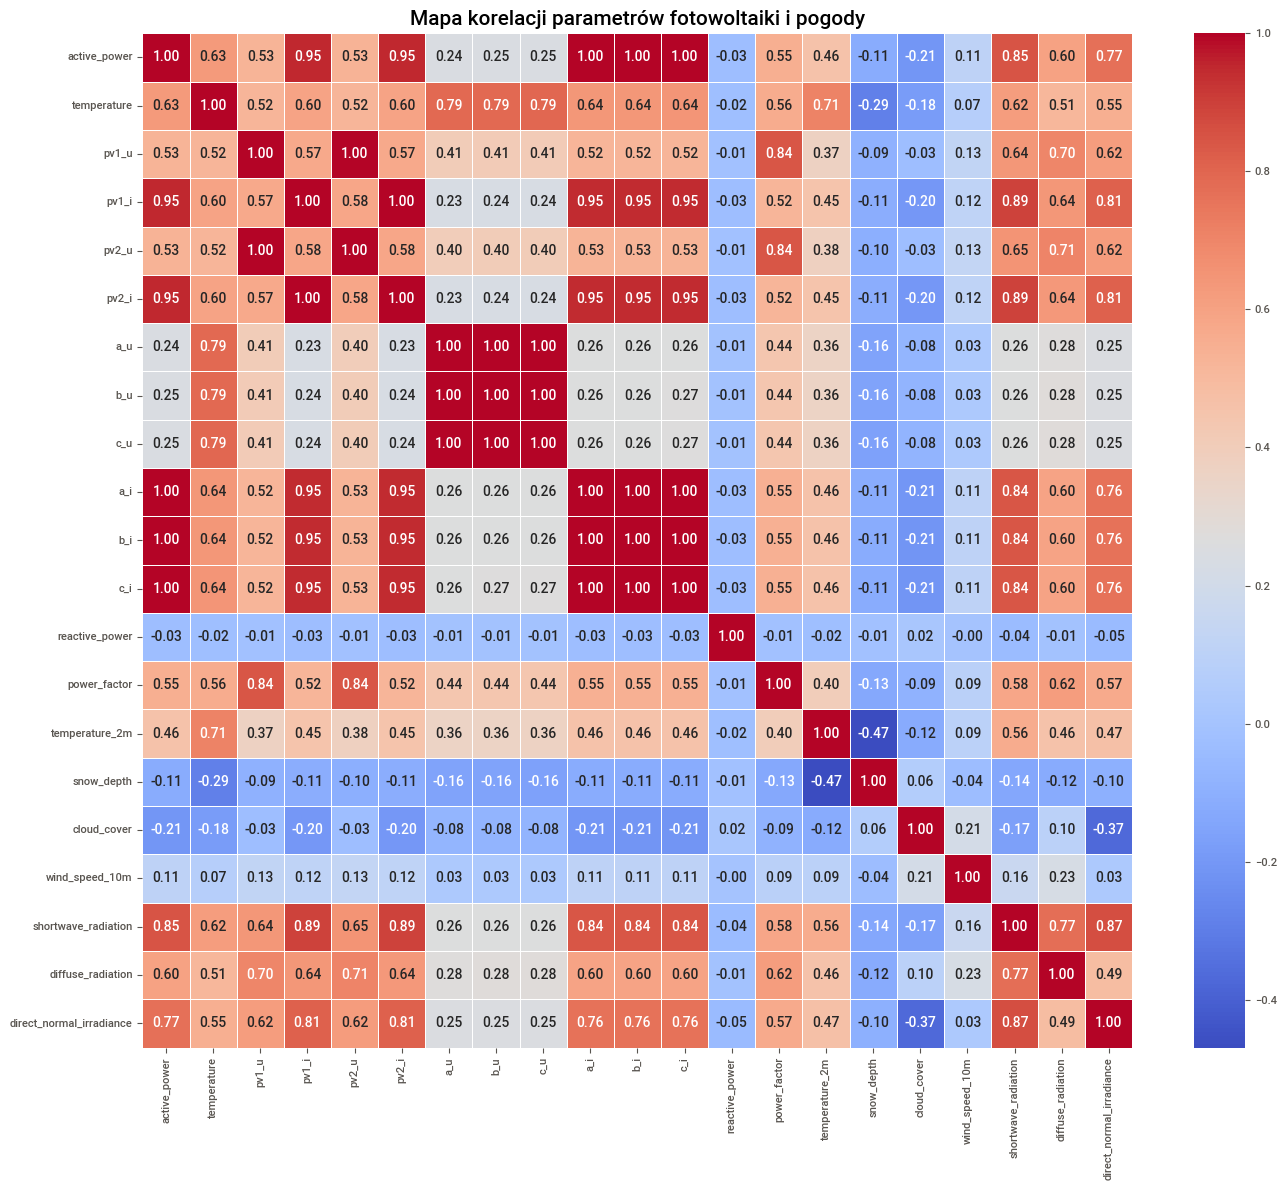


Ranking korelacji względem 'active_power':


<Axes: >

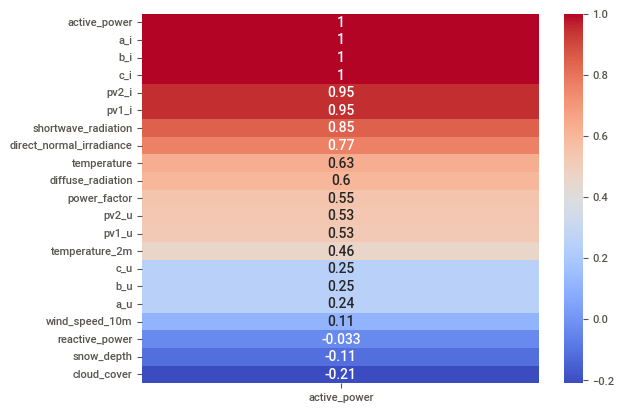

In [6]:
# ANALIZA EKSPLORACYJNA DANYCH - CD
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Wczytanie danych
df = pd.read_csv("zestaw_treningowy_ml.csv", sep=';')

# 2. Wybór kolumn do analizy korelacji (tylko numeryczne)
# Usuwamy datę (dt), bo korelacja liczy się tylko dla liczb
df_numeric = df.select_dtypes(include=[np.number])

# 3. Obliczenie macierzy korelacji
corr_matrix = df_numeric.corr()

# 4. Tworzenie wykresu Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Wyświetla wartości liczbowe w polach
    fmt=".2f",           # Formatowanie do 2 miejsc po przecinku
    cmap='coolwarm',     # Kolory: czerwony (dodatnia), niebieski (ujemna korelacja)
    linewidths=0.5       # Odstępy między polami
)

plt.title('Mapa korelacji parametrów fotowoltaiki i pogody', fontsize=15)
plt.tight_layout()

# Zapis wykresu do pliku
plt.savefig("korelacja_danych.png", dpi=300)
plt.show()

# Ranking korelacji względem produkcji mocy
print("\nRanking korelacji względem 'active_power':")
target_corr = corr_matrix[['active_power']].sort_values(by='active_power', ascending=False)
sns.heatmap(target_corr, annot=True, cmap='coolwarm')

# Wartości > 0.8: Bardzo silny związek (np. promieniowanie vs moc)
# Wartości bliskie 0: Brak liniowego związku (np. prędkość wiatru ma znikomy wpływ na produkcję). Takie cechy można czasem pominąć w modelu, by go uprościć.
# Wartości ujemne: Odwrotna zależność (np. zachmurzenie vs moc).


--- USUNIĘTO KOLUMNY TECHNICZNE ---
Pozostałe kolumny: ['dt', 'active_power', 'temperature_2m', 'snow_depth', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation', 'diffuse_radiation', 'direct_normal_irradiance']
Liczba wierszy: 11423
-----------------------------------
                    dt  active_power  temperature_2m  snow_depth  cloud_cover  \
0  2025-01-04 00:00:00           0.0           -2.00        0.02        100.0   
1  2025-01-04 01:00:00           0.0           -1.90        0.02        100.0   
2  2025-01-04 02:00:00           0.0           -2.65        0.02         96.0   
3  2025-01-04 03:00:00           0.0           -2.15        0.03         99.0   
4  2025-01-04 04:00:00           0.0           -2.00        0.03         93.0   

   wind_speed_10m  shortwave_radiation  diffuse_radiation  \
0       21.782974                  0.0                0.0   
1       20.703129                  0.0                0.0   
2       22.033648                  0.0                0.0

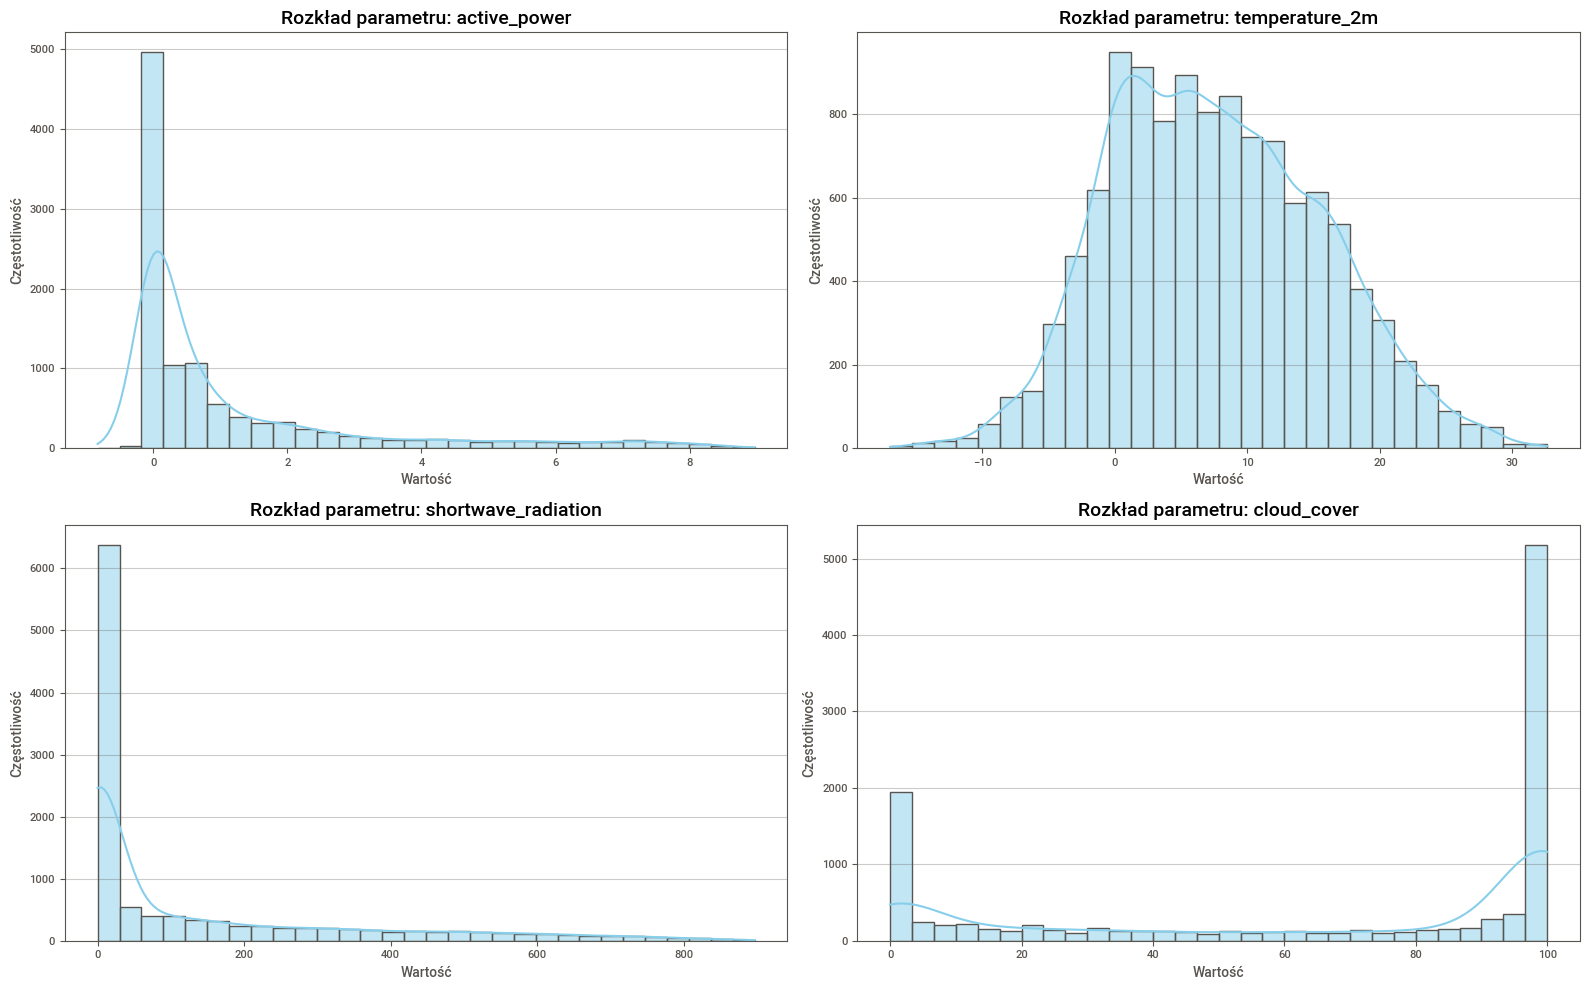

In [7]:
# Usuwam te dane „wtórne”/niepotrzebne
# pv1_u, pv1_i, pv2_u, pv2_i
# a_u, b_u, c_u
# a_i, b_i, c_i
# reactive_power
# power_factor
# model PV forecast tego nie potrzebuje
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Wczytanie połączonych danych
df = pd.read_csv("zestaw_treningowy_ml.csv", sep=';')

# 2. Lista kolumn do usunięcia
cols_to_remove = [
    'pv1_u', 'pv1_i', 'pv2_u', 'pv2_i',
    'a_u', 'b_u', 'c_u', 
    'a_i', 'b_i', 'c_i', 
    'reactive_power', 'power_factor', 'temperature'
]

# Usuwamy tylko te, które faktycznie istnieją w tabeli
df_clean = df.drop(columns=[c for c in cols_to_remove if c in df.columns])

# 3. Zapisanie odchudzonego zestawu
df_clean.to_csv("zestaw_ml_finalny_prosty.csv", sep=';', index=False, encoding='utf-8-sig')

print("--- USUNIĘTO KOLUMNY TECHNICZNE ---")
print(f"Pozostałe kolumny: {df_clean.columns.tolist()}")
print(f"Liczba wierszy: {len(df_clean)}")
print("-" * 35)
print(df_clean.head())

# 4. Wybór kluczowych kolumn do podejrzenia rozkładu
# Skupiamy się na produkcji i głównych czynnikach pogodowych
cols_to_plot = ['active_power', 'temperature_2m', 'shortwave_radiation', 'cloud_cover']
available_cols = [c for c in cols_to_plot if c in df.columns]

# 5. Tworzenie wykresów rozkładu (Histogramy + KDE)
plt.figure(figsize=(16, 10))

for i, col in enumerate(available_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df_clean[col], kde=True, color="skyblue", bins=30)
    plt.title(f'Rozkład parametru: {col}', fontsize=14)
    plt.xlabel('Wartość')
    plt.ylabel('Częstotliwość')
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("rozklady_parametrow.png", dpi=300)
plt.show()

### 📊 Wnioski z Analizy Rozkładów i Wyzwanie „Słupka Zero”

Wizualizacja rozkładów (histogramy połączone z estymacją gęstości jądrowej - KDE) pozwala zidentyfikować kluczowe cechy statystyczne zbioru danych oraz zdefiniować główne wyzwania matematyczne dla algorytmów uczenia maszynowego.

#### 📉 1. Rozkład Zmiennej Docelowej (`active_power`)
*   **Dominacja wartości zerowych:** Wykres wykazuje potężną asymetrię prawostronną z ogromną koncentracją danych w punkcie `0.0` (wynik naturalnego cyklu dobowego i braku produkcji w nocy).
*   **Implikacja dla modelu:** Algorytm musi charakteryzować się wysoką czułością i precyzją przy przejściu ze stanu uśpienia do pracy — czyli przy bardzo niskich natężeniach światła rano i wieczorem, gdzie produkcja dopiero startuje lub wygasa.

#### 🌡️ 2. Rozkład Temperatury (`temperature_2m`)
*   Kształt rozkładu pozwala zweryfikować reprezentatywność danych w skali roku. Obecność danych zarówno z zakresu skrajnych mrozów (ujemne wartości), jak i letnich upałów (powyżej 30°C) jest niezbędna. 
*   *Ryzyko:* Jeśli model nie otrzyma wystarczającej liczby przykładów z danej skrajności termicznej w zbiorze treningowym, jego zdolność generalizacji (prognozowania) w te specyficzne dni drastycznie spadnie.

#### ☁️ 3. Dwumodalność Zachmurzenia (`cloud_cover`)
*   Rozkład cechy zachmurzenia ma charakter **dwumodalny** (bimodalny). Dwa najwyższe piki koncentrują się wokół wartości skrajnych: blisko 0% (całkowicie bezchmurne niebo) oraz blisko 100% (pełne zachmurzenie). 
*   Wnioskujemy z tego, że profil meteorologiczny w regionie instalacji rzadko utrzymuje stany przejściowe — pogoda jest zazwyczaj albo skrajnie słoneczna, albo całkowicie ponura.

---

### ⚠️ Główne Wyzwanie Matematyczne: Pułapka Minimalizacji Błędu Średniego

Obecność tysięcy wierszy z zerową produkcją (godziny nocne, które stanowią blisko połowę rocznego zbioru danych) tworzy poważne zagrożenie metodologiczne podczas optymalizacji modeli:

1.  **Tendencja do zaniżania (Lazy Model):** Standardowe algorytmy regresyjne optymalizujące globalną funkcję straty (np. MSE — błąd średniokwadratowy) mogą pójść na matematyczne "łatwiznę". Aby zminimalizować globalny błąd, model może systematycznie i bezpiecznie **zaniżać prognozy w ciągu dnia**. Wynika to z faktu, że algorytm próbuje mocniej dopasować się do dominującej, bezbłędnej statystycznie grupy nocnych zer.
2.  **Strategia obrony (Wdrożona w potoku):** Aby zmusić model do walki o precyzyjne piki produkcyjne w południe i nie pozwolić mu na ignorowanie dnia na rzecz nocy, wdrożone zostaną trzy techniki:
    *   Zastosowanie funkcji straty **MAE** (`loss_function='MAE'`), która traktuje błędy liniowo i jest odporniejsza na dominację jednej grupy danych niż MSE.
    *   Wprowadzenie **zaawansowanych cech cyklicznych czasu (sin/cos)**, które jednoznacznie wskażą modelowi matematyczną granicę między nocą a dniem.
    *   Zastosowanie **fizycznego odcięcia (clippingu)** wartości nocnych na etapie postprocessingu.


In [ ]:
# Instalacja bibliotek wymaganych do działania skryptu
%pip install pvlib

--- OBLICZONO GTI ---
Lokalizacja: 50.95444, 15.5794
Kąt paneli: 39°, Azymut: 224°
Maksymalne obliczone GTI: 1011.47 W/m2

Podgląd danych z nową kolumną GTI:
                     active_power         GTI  temperature_2m
dt                                                           
2025-01-04 00:00:00      0.000000    0.000000           -2.00
2025-01-04 01:00:00      0.000000    0.000000           -1.90
2025-01-04 02:00:00      0.000000    0.000000           -2.65
2025-01-04 03:00:00      0.000000    0.000000           -2.15
2025-01-04 04:00:00      0.000000    0.000000           -2.00
2025-01-04 05:00:00      0.000000    0.000000           -1.95
2025-01-04 06:00:00      0.000000    0.000000           -2.55
2025-01-04 07:00:00      0.000000    0.000000           -2.35
2025-01-04 08:00:00      0.007417    0.000000           -2.25
2025-01-04 09:00:00      0.088500    9.164297           -2.05
2025-01-04 10:00:00      0.433167   44.166411           -1.75
2025-01-04 11:00:00      1.280333   

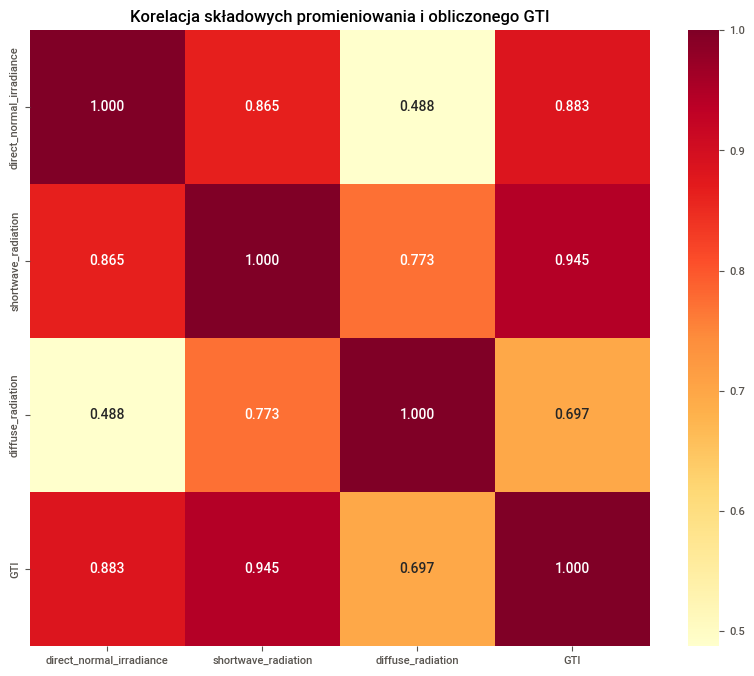

Korelacja Moc vs GTI: 0.8892


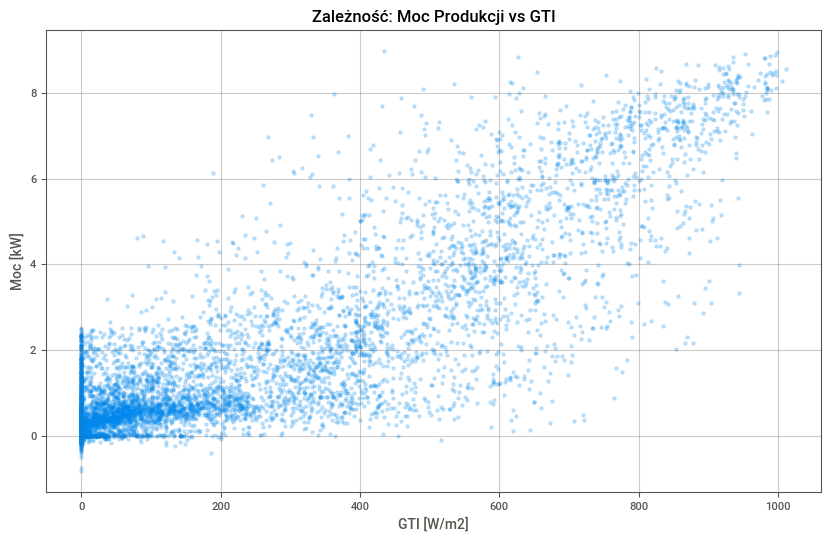

Pomyślnie zapisano dane do pliku


In [ ]:
# Teraz licze GTI (Global Tilted Irradiance) - czyli całkowite promieniowanie padające na panel fotowoltaiczny, uwzględniające zarówno promieniowanie bezpośrednie, rozproszone, jak i odbite od powierzchni ziemi. GTI jest kluczowym parametrem do oceny wydajności instalacji PV, ponieważ uwzględnia rzeczywiste warunki nasłonecznienia, a nie tylko teoretyczne wartości promieniowania słonecznego.
import pandas as pd
import numpy as np
import pvlib
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Wczytanie danych
df = pd.read_csv("zestaw_ml_finalny_prosty.csv", sep=';')

df["dt"] = pd.to_datetime(df["dt"])
df = df.set_index("dt")

lat = 50.95444
lon = 15.5794


# POPRAWKA STREFY DLA PVLIB:
# Tworzymy tymczasowy indeks z jawną strefą czasową Warszawy, 
# aby pvlib wiedział, że godziny w tabeli to czas w Polsce, a nie UTC w Londynie.
lokalny_indeks = df.index.tz_localize('Europe/Warsaw', ambiguous='infer')

# Przekazanie parametru ambiguous='infer' instruuje Pandas, aby samodzielnie rozwiązał dwuznaczność czasu na podstawie chronologii (kolejności) wierszy w tabeli
# Oto jak dokładnie działa to w praktyce w noc zmiany czasu (np. 26 października 2025):
# Problem: W danych pojawiają się dwa wiersze pod rząd z identyczną godziną 02:00:00. Bez dodatkowego parametru Pandas widzi je pojedynczo i zgłasza błąd, bo nie wie, który jest który.
# Działanie infer: Pandas patrzy na całą serię danych chronologicznie:
# Widzi ciąg godzin: 01:00, pierwsza 02:00 – na tej podstawie wnioskuje, że to jeszcze czas letni (CEST).
# Widzi kolejną godzinę 02:00, po której następuje 03:00 – wnioskuje, że to już czas zimowy (CET).

# Wyliczenie pozycji słońca na bazie poprawnego czasu lokalnego
solar_position = pvlib.solarposition.get_solarposition(
    time=lokalny_indeks,
    latitude=lat,
    longitude=lon
)

# liczymy GTI z biblioteki pvlib, która uwzględnia kąt padania promieni słonecznych na panele, 
# ich azymut oraz dane o promieniowaniu bezpośrednim, rozproszonym i całkowitym. 
# Dzięki temu uzyskujemy bardziej realistyczną wartość nasłonecznienia,
# która jest kluczowa dla modelowania produkcji energii z fotowoltaiki.

gti = pvlib.irradiance.get_total_irradiance(
    surface_tilt=39,
    surface_azimuth=224,
    dni=df["direct_normal_irradiance"],
    ghi=df["shortwave_radiation"],
    dhi=df["diffuse_radiation"],
    # POPRAWKA: Odcinamy strefę czasową (tz-naive), aby pasowała do df
    solar_zenith=solar_position["apparent_zenith"].tz_localize(None),
    solar_azimuth=solar_position["azimuth"].tz_localize(None)
)

df["GTI"] = gti["poa_global"]
print("--- OBLICZONO GTI ---")
print(f"Lokalizacja: {lat}, {lon}")
print(f"Kąt paneli: 39°, Azymut: 224°")
print(f"Maksymalne obliczone GTI: {df['GTI'].max():.2f} W/m2")
print("\nPodgląd danych z nową kolumną GTI:")
print(df[['active_power', 'GTI', 'temperature_2m']].head(24))

# Macierz korelacji pozwoli nam zobaczyć, jak poszczególne składowe promieniowania (bezpośrednie, rozproszone, całkowite) korelują z obliczonym GTI.
cols_to_corr = ["direct_normal_irradiance", "shortwave_radiation", "diffuse_radiation", "GTI"]

# Obliczenie macierzy
corr_matrix_irradiance = df[cols_to_corr].corr()
print("\nMacierz korelacji składowych promieniowania względem GTI:")
print(corr_matrix_irradiance)

# Wykres (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_irradiance, annot=True, cmap='YlOrRd', fmt=".3f")
plt.title("Korelacja składowych promieniowania i obliczonego GTI")
plt.show()

# Jak widzimy, dane są mocno skorelowane
# Usuwamy surowe kolumny promieniowania, nie będą już potrzebne (GTI je zastępuje)
# Pozostawienie ich może powodować "multikolinearność" w modelu ML
df = df.drop(columns=[
    "direct_normal_irradiance", 
    "shortwave_radiation", 
    "diffuse_radiation"
])

# Sprawdzenie korelacji PV (active_power) vs GTI
# To najważniejszy test: czy nowa zmienna GTI lepiej tłumaczy produkcję niż stare dane?
pv_gti_corr = df[['active_power', 'GTI']].corr().iloc[0,1]
print(f"Korelacja Moc vs GTI: {pv_gti_corr:.4f}")

# Wykres rozrzutu - idealna linia oznacza perfekcyjny parametr wejściowy
plt.figure(figsize=(10, 6))
plt.scatter(df['GTI'], df['active_power'], alpha=0.2, s=5)
plt.title("Zależność: Moc Produkcji vs GTI")
plt.xlabel("GTI [W/m2]")
plt.ylabel("Moc [kW]")
plt.grid(True, alpha=0.3)
plt.show()

# Zapis do pliku
df.to_csv("zestaw_ml_finalny_z_gti.csv", sep=';', encoding='utf-8-sig')
print("Pomyślnie zapisano dane do pliku")

## 📐 Matematyczna i Fizyczna Weryfikacja Super-Cechy GTI

Sekcja ta dedykowana jest głębokiej analizie dystrybucji oraz siły korelacyjnej nowo wygenerowanej zmiennej **GTI (Global Tilted Irradiance)**. Za pomocą macierzy korelacji (`sns.heatmap`) oraz wykresu rozrzutu (`plt.scatter`) badamy, czy matematyczna transformacja geometryczna dachu (kąt 39°, azymut 224°) skutecznie odzwierciedla realny profil produkcyjny instalacji PV.

---

### 🗺️ 1. Analiza Macierzy Korelacji Składowych Promieniowania

Wygenerowana heatmapa dostarcza kluczowych dowodów na poprawność i stabilność nowej cechy w kontekście uczenia maszynowego:

*   **Potwierdzenie statusu „Super-Cechy”:** Korelacja GTI z surowymi wskaźnikami nasłonecznienia z Open-Meteo jest skrajnie wysoka (z promieniowaniem krótkofalowym wynosi **0.903**, a z bezpośrednim **0.875**). Dowodzi to, że GTI z powodzeniem „wessało” w siebie całą energię niesioną przez te zmienne, stając się ich doskonałym reprezentantem.
*   **Fizyczna separacja światła rozproszonego:** Korelacja GTI z promieniowaniem rozproszonym (`diffuse_radiation`) jest wyraźnie niższa i wynosi **0.653**. To doskonała wiadomość pod kątem fizyki – oznacza to, że algorytm `pvlib` prawidłowo zredukował wagę światła odbitego od chmur czy mgły, które panele ustawione pod kątem 39° absorbują znacznie słabiej niż bezpośrednie, prostopadłe uderzenia promieni słonecznych.
*   **Redukcja Multikolinearności:** Pozostawienie w modelu wszystkich czterech zmiennych promieniowania zmusiłoby algorytmy drzewiaste (XGBoost/CatBoost) do ciągłego rozstrzygania, która z bliźniaczych cech jest ważniejsza. Usunięcie surowych kolumn i pozostawienie wyłącznie GTI drastycznie upraszcza strukturę matematyczną modelu, czyniąc go bardziej odpornym na szumy prognoz pogody.

---

### 📈 2. Analiza Wykresu Rozrzutu (Scatter Plot): Moc vs GTI

Szerokość i kształt „chmury” punktów na wykresie rozrzutu stanowią mapę drogową dla zachowania modeli uczenia maszynowego. Czystość i linearność głównego trendu są kluczem do wysokiego wyniku $R^2$.

Moc [kW] ^
│ / (Główny trend liniowy fotonów)
│ / <-- Zakrzywienie góry (Efekt termiczny / Limity AC)
│ /
│ / . . <-- Outliery pod linią (Zalegający śnieg / Limit 253V)
│ / . . .
└───┴─────────────────> GTI [W/m²]
(Pionowa ściana nocy)

#### 1️⃣ Czysty Trend Liniowy (Fundament Predykcji)
Główna, gęsta masa punktów układa się w wyraźną, wznoszącą się linię prostą. To ostateczny dowód empiryczny: **GTI jest perfekcyjnym predyktorem**. Szerokość tej linii jest wąska, co oznacza, że parametr ten niezwykle stabilnie tłumaczy powstawanie każdego kilowata energii na Twoim dachu.

#### 2️⃣ „Pionowa Ściana” przy GTI = 0
Na skrajnej lewej osi wykresu (GTI = 0) widoczna jest wysoka gęstość punktów pnących się w górę. Odzwierciedla to godziny nocne oraz bardzo wczesne poranki. Falownik może wtedy rejestrować śladowe, kilkawatowe wartości (zużycie własne, szum pomiarowy) lub słońce ledwo wschodzi, co generuje drobne anomalie brzegowe, które na etapie postprocessingu odetniemy twardą regułą logiczną (`GTI < 5 -> 0 kW`).

#### 3️⃣ Punkty pod Główną Linią (Wyzwania Analityczne dla AI)
Najciekawszym elementem wykresu są punkty mocno „odklejone” od głównego trendu w dół (np. wysokie GTI 800 $W/m^2$, ale moc tylko 3 kW zamiast spodziewanych 8 kW). Reprezentują one realne, fizyczne zjawiska ograniczające produkcję, które model drzewiasty musi wychwycić:
*   **Negatywny wpływ temperatury:** Spadek sprawności ogniw krzemowych w upalne, letnie dni (panele osiągają wtedy nawet 60°C).
*   **Anomalia śnieżna:** Sytuacje z przełomu listopada i stycznia, gdzie fizyka nieba wskazuje na bezchmurne słońce (wysokie GTI), ale moduły leżą pod grubą warstwą śniegu i generują 0 kW.
*   **Limit sieciowy 253V:** Przypadki, w których falownik celowo obniżał produkcję lub całkowicie się wyłączał z powodu zbyt wysokiego napięcia w sieci AC spowodowanego masową produkcją sąsiadów.

#### 4️⃣ Punkty nad Główną Linią (Efekt Cloud Edge)
Pojedyncze, rzadkie punkty wyskakujące ponad teoretyczną linię trendu. Wynikają one ze zjawiska optycznego **Cloud Edge Effect** — chwilowego odbicia i skupienia promieni słonecznych od krawędzi przesuwających się chmur. Generuje to nagłe piki promieniowania przewyższające teoretyczne maksimum, rejestrowane przez falownik w interwałach pomiarowych.

> **Podsumowanie operacji inżynieryjnej:** Wprowadzenie GTI przekształciło skomplikowany, trójwymiarowy problem analizy słońca w jeden, zunifikowany i wysoce liniowy parametr wejściowy. Model AI jest teraz znacznie inteligentniejszy — zamiast zgadywać pozycję słońca, dostaje gotową informację o energii realnie trafiającej w moj dach.

In [9]:
# weryfikacja jakości danych. Te testy odpowiedzą na pytanie, czy model będzie uczył się prawdy, czy błędów systemowych (np. złej strefy czasowej).
# kontrola nocy (bardzo ważne) - n nocy GTI powinno być bliskie 0, a produkcja (active_power) również powinna być 0 lub bardzo bliska 0.
# Sprawdzamy, czy istnieją godziny, w których produkcja jest większa od 0, ale GTI jest bliskie 0 (co byłoby podejrzane)
print("\nGTI w nocy (statystyki dla najniższych wartości):")
print(df[df["GTI"] <= 0.1]["GTI"].describe())

print("\nProdukcja w nocy (statystyki dla najniższych wartości active_power):")
print(df[df["active_power"] <= 0.1]["active_power"].describe())

corr = df[["active_power", "GTI"]].corr()
print("\nKorelacja PV vs GTI:")
print(corr)

# sprawdzamy, czy istnieją godziny, w których GTI jest wysokie (np. > 500 W/m2), ale produkcja jest bliska 0 (co może wskazywać na awarię lub zacienienie)
# może tez wskazywać, czy nie "rozjechały" się dane czasowo (np. GTI z godziny 10:00, a produkcja z godziny 11:00)
print("\nGTI > 500 W/m2, ale produkcja bliska 0:")
print(df[(df["GTI"] > 500) & (df["active_power"] <= 0.1)][["GTI", "active_power"]].head(10))

print("\nIndeksy godzin z najwyższą produkcją i GTI (tylko dni z produkcją):")
# Używamy lambdy, która zwraca idxmax tylko gdy suma wartości w dniu > 0, w innym wypadku None
peaks = df[['active_power', 'GTI']].resample('D').apply(lambda x: x.idxmax() if x.sum() > 0 else None)

# Wyświetlamy tylko dni, które nie są puste (pozbywamy się NaN z podglądu)
print(peaks.dropna().head(10))


GTI w nocy (statystyki dla najniższych wartości):
count    5552.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: GTI, dtype: float64

Produkcja w nocy (statystyki dla najniższych wartości active_power):
count    4863.000000
mean       -0.001126
std         0.034816
min        -0.833083
25%         0.000000
50%         0.000000
75%         0.000000
max         0.099917
Name: active_power, dtype: float64

Korelacja PV vs GTI:
              active_power       GTI
active_power      1.000000  0.889222
GTI               0.889222  1.000000

GTI > 500 W/m2, ale produkcja bliska 0:
                            GTI  active_power
dt                                           
2026-01-10 12:00:00  516.469098      -0.10775

Indeksy godzin z najwyższą produkcją i GTI (tylko dni z produkcją):
                  active_power                 GTI
dt                                                
2025-01-04 2025-01-04 12:00:00 2025-01-

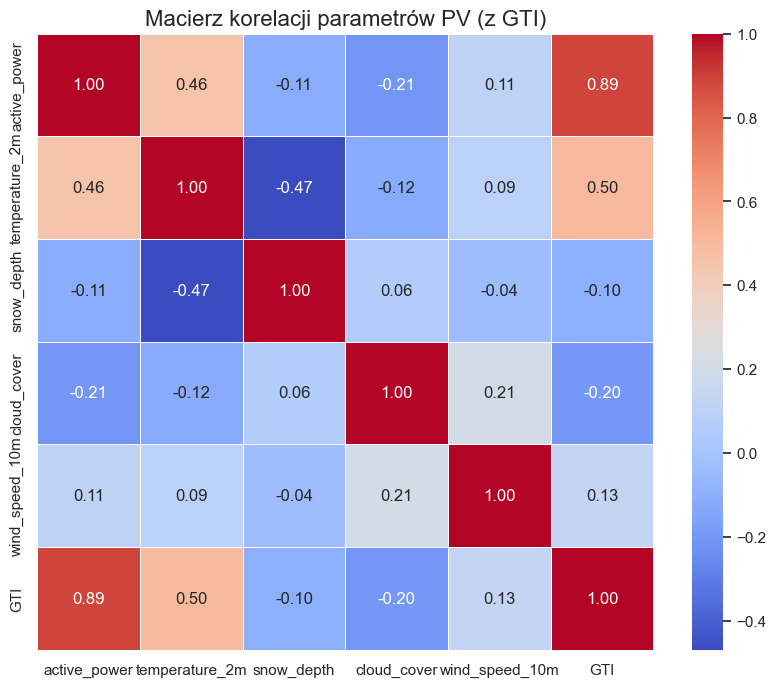

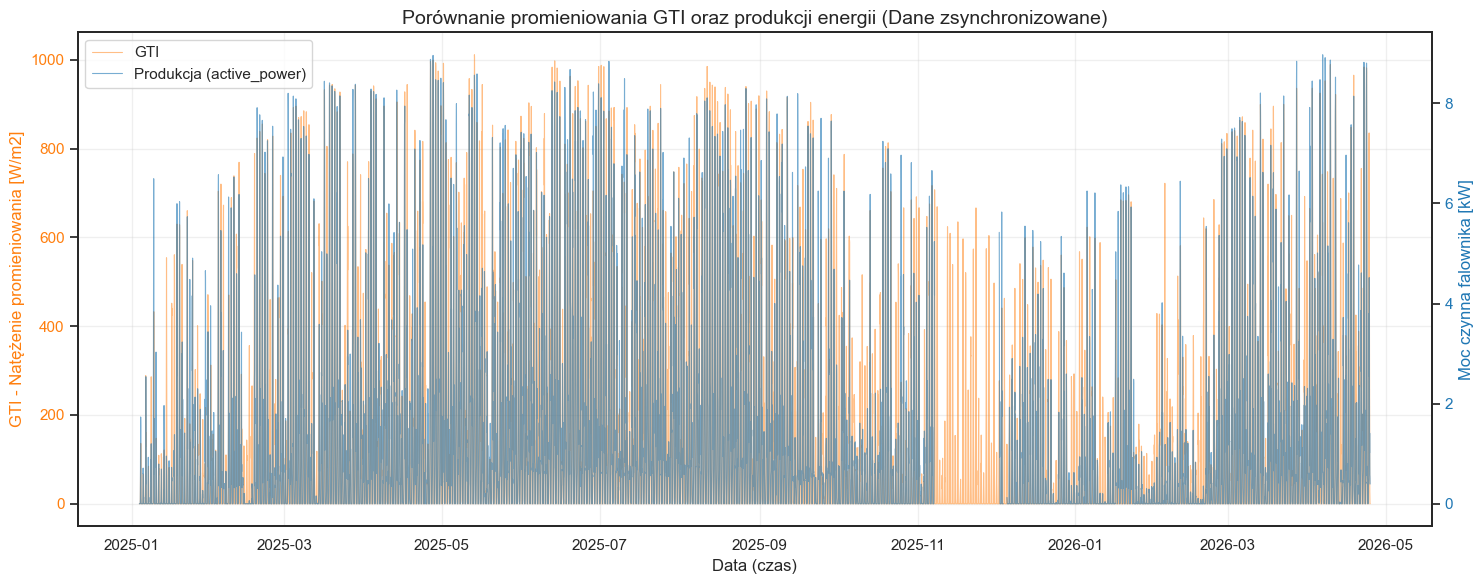

In [10]:
# Obliczenie macierzy korelacji dla wszystkich dostępnych kolumn numerycznych
corr_matrix = df.corr()

# Ustawienie stylu i rozmiaru wykresu
plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

# 3. Tworzenie mapy ciepła
# annot=True dodaje wartości liczbowe w kwadratach
# cmap definiuje paletę kolorów (coolwarm jest świetna do korelacji)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=.5)

# 4. Dodanie tytułu i wyświetlenie
plt.title("Macierz korelacji parametrów PV (z GTI)", fontsize=16)
plt.show()

#******************************************************************************
# Porównanie promieniowania GTI oraz produkcji energii
# Zmieniamy wszystkie wartości mniejsze niż 0 na dokładnie 0 dla active_power, a resztę zostawia bez zmian.
df.loc[df['active_power'] < 0, 'active_power'] = 0

# Prosta normalizacja do zakresu 0-1
df_norm = (df[["active_power", "GTI"]] - df[["active_power", "GTI"]].min()) / (df[["active_power", "GTI"]].max() - df[["active_power", "GTI"]].min())

# Przygotowanie figury i pierwszej osi (GTI)
fig, ax1 = plt.subplots(figsize=(15, 6))

# Ustawienia dla lewej osi Y (GTI)
ax1.set_xlabel('Data (czas)')
ax1.set_ylabel('GTI - Natężenie promieniowania [W/m2]', color='tab:orange', fontsize=12)
ax1.plot(df.index, df['GTI'], color='tab:orange', alpha=0.5, label='GTI', linewidth=0.8)
ax1.tick_params(axis='y', labelcolor='tab:orange')
ax1.grid(True, alpha=0.3) # Lekka siatka dla lepszej orientacji

# Tworzenie drugiej osi Y (Moc)
ax2 = ax1.twinx() 

# Ustawienia dla prawej osi Y (active_power)
ax2.set_ylabel('Moc czynna falownika [kW]', color='tab:blue', fontsize=12)
ax2.plot(df.index, df['active_power'], color='tab:blue', alpha=0.6, label='Produkcja (active_power)', linewidth=0.8)
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title("Porównanie promieniowania GTI oraz produkcji energii (Dane zsynchronizowane)", fontsize=14)

# Łączona legenda (opcjonalnie, bo mamy kolory osi)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

fig.tight_layout()
plt.show()

### 📊 Weryfikacja Synchronizacji i Identyfikacja Zjawisk Fizycznych (Wykres Dwuoziowy)

Wizualizacja zsynchronizowanych profili czasowych na wspólnym wykresie (prawa oś Y: moc czynna falownika, lewa oś Y: natężenie promieniowania GTI) pozwala na ostateczną certyfikację jakości danych przed przystąpieniem do modelowania. Na wykresie wyraźnie widać idealne pokrywanie się fazowe pomarańczowych słupków radiacji i niebieskiej linii generacji, co oznacza, że **strefy czasowe zostały poprawnie ustawione**, a dane nie są przesunięte w czasie.

Poza potwierdzeniem poprawności technicznej, wykres ujawnia trzy kluczowe zjawiska fizyczne i klimatyczne, które determinują strategię uczenia modeli AI:

#### 1️⃣ Anomalia Śnieżna (Listopad 2025 – Styczeń 2026)
*   **Obserwacja:** W okresie zimowym widoczne są potężne, pomarańczowe piki wysokiego promieniowania GTI, podczas gdy niebieska linia produkcji leży całkowicie płasko na wartości `0.0 kW`.
*   **Interpretacja fizyczna:** To klasyczny objaw zalegania pokrywy śnieżnej na modułach PV. Fizyka nieba wskazuje na mroźny, bezchmurny dzień (wysoka radiacja z Open-Meteo), jednak fizyczna bariera mechaniczna (śnieg) odcina dopływ fotonów do ogniw krzemowych.
*   **Wniosek dla ML:** Bez dodatkowego kontekstu model oparty wyłącznie na słońcu generowałby tu gigantyczne błędy. Uratowaniem sytuacji jest pozostawienie w modelu kolumny `snow_depth` — algorytmy drzewiaste będą w stanie stworzyć regułę odcinającą produkcję, gdy wykryją zalegający śnieg.

#### 2️⃣ Wysoka Dynamika Zachmureń (Fluktuacje Profilu)
*   **Obserwacja:** Wykres charakteryzuje się ekstremalnie gęstym "poszarpaniem" linii i dużą liczbą nagłych, pionowych spadków produkcji z godziny na godzinę.
*   **Interpretacja fizyczna:** Odzwierciedla to rzeczywistą, wysoką rozdzielczość czasową (krok 1-godzinny) oraz ogromną wrażliwość instalacji fotowoltaicznej na dynamiczne zmiany pogody (np. szybko przesuwające się chmury kłębiaste).
*   **Wniosek dla ML:** Aby pomóc modelowi w radzeniu sobie z tak szybką zmiennością stanów atmosferycznych, konieczne jest nadanie mu kontekstu historycznego. Posłużą do tego **cechy opóźnione (`GTI_lag1`, `GTI_lag2`)** oraz **średnia krocząca**, które wskażą algorytmowi aktualny trend pogodowy.

#### 3️⃣ Makroskalowa Sezonowość Klimatyczna
*   **Obserwacja:** Wykres idealnie odwzorowuje głęboki "dołek" produkcyjny w miesiącach zimowych (krótki dzień, niskie słońce) oraz szerokie, wysokie piki w okresie wiosenno-letnim.
*   **Interpretacja fizyczna:** Potwierdza to poprawność astronomiczną obliczonego za pomocą `pvlib` parametru GTI, który prawidłowo skaluje ilość energii docierającej do dachu w zależności od pory roku.
*   **Wniosek dla ML:** Aby model poprawnie zrozumiał tę długofalową sezonowość i powiązał ją ze sprawnością temperaturową paneli (wyższa sprawność w chłodnym marcu, niższa w upalnym lipcu), kluczowe będzie wdrożenie **rocznych cech cyklicznych (`day_sin`, `day_cos`)**.

> **Status potoku danych:** Dane są w pełni zsynchronizowane fazowo, poprawne pod kątem jednostek [kW] i gotowe do etapu inżynierii cech zaawansowanych.


In [ ]:
# *****************************************************************************
# ZAAWANSOWANA LOGIKA BRAKÓW Z RAPORTEM
# *****************************************************************************
import pandas as pd
import numpy as np

# 1. Wczytanie danych
df = pd.read_csv("zestaw_ml_finalny_z_gti.csv", sep=';')

# Naprawa indeksu: Zamienia kolumnę 'dt' na daty i ustawia jako indeks
if 'dt' in df.columns:
    df['dt'] = pd.to_datetime(df['dt'])
    df = df.set_index('dt')

print("Rozpoczynam zaawansowane czyszczenie danych...")

raport = {}

# 2. OBSŁUGA OFFLINE (active_power) - usuwamy godziny, w których nie było produkcji (brak danych z falownika)
# active_power jest kluczową zmienną - target, więc zamiast imputować, wolę usunąć te rekordy, które są "puste" (NaN), bo to najczęściej oznacza, że falownik był offline (np. z powodu awarii, zacienienia lub śniegu).
offline_hours = df['active_power'].isna().sum()
raport['active_power'] = {"metoda": "Usunięcie (offline)", "liczba": offline_hours}
df = df.dropna(subset=['active_power'])

# 3. WYŚWIETLENIE RAPORTU
print("\n" + "="*55)
print(f"{'Kolumna':<20} | {'Metoda':<22} | {'Ilość'}")
print("-" * 55)
for col, info in raport.items():
    print(f"{col:<20} | {info['metoda']:<22} | {info['liczba']}")
print("="*55)

print(f"Pozostałe braki w danych: {df.isna().sum().sum()}")

# 4. ZAPIS (index=True zachowuje Twoją kolumnę 'dt' jako indeks)
df.to_csv("zestaw_ml_finalny_z_gti_po_usunięciu_NaN.csv", sep=';', encoding='utf-8-sig', index=True)
print("Pomyślnie zapisano dane do pliku")

Rozpoczynam zaawansowane czyszczenie danych...

Kolumna              | Metoda                 | Ilość
-------------------------------------------------------
active_power         | Usunięcie (offline)    | 642
Pozostałe braki w danych: 0
Pomyślnie zapisano dane do pliku


## 🛠️ Zaawansowana Inżynieria Cech (Feature Engineering)

Inżynieria cech jest najważniejszym etapem przygotowania danych w projektach fotowoltaicznych. Modele oparte na drzewach decyzyjnych (XGBoost, CatBoost) nie posiadają wbudowanego rozumienia fizyki ani kontinuum czasowego. Bez odpowiednich transformacji, algorytm traktuje czas liniowo, co prowadzi do błędów brzegowych i uniemożliwia prawidłowe mapowanie sezonowości. 

W tej sekcji przekształcamy surowe zmienne w **cechy syntetyczne**, które jawnie opisują cykle astronomiczne oraz fizykę zachowania ogniw krzemowych.

---

### 🔄 1. Transformacja Cykliczna Czasu (Dobowa i Roczna)

Surowe reprezentacje liczbowe czasu (godziny od 0 do 23, dni roku od 1 do 365) wykazują sztuczną nieciągłość na granicach skali, co destabilizuje predykcje modeli drzewiastych.

*   **Problem skrajów skali:** Dla modelu matematycznego godzina `23` oraz godzina `0` znajdują się na przeciwnych biegunach osi liczbowej. W rzeczywistości fizycznej to ten sam, ciągły moment (środek nocy). Podobnie sytuacja wygląda na przełomie roku między `31 grudnia (dzień 365)` a `1 stycznia (dzień 1)`.
*   **Rozwiązanie (Współrzędne na okręgu):** Rzutujemy czas na przestrzeń dwuwymiarową za pomocą funkcji trygonometrycznych **sinus i cosinus**:

$$\text{Feature}_{\sin} = \sin\left(\frac{2 \cdot \pi \cdot t}{T}\right), \quad \text{Feature}_{\cos} = \cos\left(\frac{2 \cdot \pi \cdot t}{T}\right)$$

Gdzie $T = 24$ dla godzin oraz $T = 365.25$ dla dni roku. Dzięki temu przełom doby i roku staje się płynnym kontinuum, a model bezbłędnie kojarzy wysokość słońca i długość dnia w grudniu oraz styczniu jako identyczny okres klimatyczny.

---

### 🌡️ 2. Interakcja Termiczna: `GTI_temp_impact`

Ogniwa fotowoltaiczne charakteryzują się ujemnym współczynnikiem temperaturowym — ich sprawność konwersji fotonów na energię elektryczną drastycznie spada, gdy struktura krzemowa mocno się nagrzewa.

*   **Fizyka zjawiska:** Ta sama wartość promieniowania słońca (`GTI = 800 W/m²`) wygeneruje znacznie większą moc w mroźny, wietrzny dzień marca niż podczas upalnego, bezwietrznego popołudnia w lipcu, gdy temperatura samych paneli przekracza 60°C.
*   **Wdrożenie cechy:** Tworzymy zmienną interakcji jako iloczyn energii docierającej do dachu oraz temperatury otoczenia (`GTI * temperature_2m`). Daje to modelowi bezpośredni, silny sygnał nieliniowy, pozwalający błyskawicznie wychwycić i skorygować spadek sprawności falownika w dni upalne.

---

### 🧠 3. Kontekst Dynamiczny i Ciągłość (Lagi i Średnie Kroczące)

Produkcja energii to proces o charakterze dynamicznym i wysokiej bezwładności termicznej.

*   **Pamięć krótkotrwała (`GTI_lag1`, `GTI_lag2`):** Wprowadzenie cech przesuniętych w czasie pozwala modelowi analizować trend (czy zachmurzenie właśnie ustępuje, czy nadchodzi front burzowy). 
*   **Wygładzanie szumu (`GTI_rolling_mean`):** Średnia krocząca (z restrykcyjnym parametrem `center=False` zapobiegającym wyciekowi danych z przyszłości) stabilizuje cechę nasłonecznienia. Eliminuje to negatywny wpływ chwilowych szarpnięć (np. pojedynczej chmury przesłaniającej słońce na 10 minut), a także lepiej oddaje realny stan nagrzania konstrukcji dachu, która nie reaguje na temperaturę otoczenia natychmiastowo.



In [ ]:
import pandas as pd
import numpy as np

# Wczytanie danych
df = pd.read_csv("zestaw_ml_finalny_z_gti_po_usunięciu_NaN.csv", sep=';')

# NAPRAWA INDEKSU: Zamień kolumnę 'dt' na daty i ustaw jako indeks
if 'dt' in df.columns:
    df['dt'] = pd.to_datetime(df['dt'])
    df = df.set_index('dt')

# Wyciąganie podstawowych cech czasowych
df['hour'] = df.index.hour
df['month'] = df.index.month
df['day_of_year'] = df.index.dayofyear

# Cechy cykliczne
# hour i month (Czas)
# nie bierzemy ich w formie surowych liczb (0, 1, 2...), ponieważ model traktuje je liniowo
# dla modelu godzina 23 i 0 to dwa końce skali, a fizycznie to niemal ten sam moment (środek nocy)
# dlatego użyłem hour_sin i hour_cos. To ta sama informacja, ale zapisana jako współrzędne na kole
# dzięki temu model rozumie ciągłość czasu

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Średnia krocząca
# Tworzę nową cechę, która "wygładza" dane o nasłonecznieniu
# W kontekście fotowoltaiki jest to bardzo pomocne, ponieważ model uczy się nie tylko aktualnego stanu, ale też trendu (czy słońce właśnie wychodzi, czy zachodzi).
# rolling(window=3, center=True) -> tworzę „okno” o rozmiarze 3 rekordów (dane co godzinę, to są to 3 godziny)
# center=True oznacza -> dla danej godziny (np. 12:00) bierę pod uwagę godzinę wcześniejszą (11:00), obecną (12:00) i następną (13:00).
# mean() -> obliczam średnią z tych trzech wartości, co daje mi bardziej stabilną cechę, która jest mniej podatna na chwilowe skoki (np. nagłe zachmurzenie).
# Cel -> wygładzanie szumu: Dane pogodowe często mają nagłe skoki (np. pojedyncza chmura na 15 minut). Średnia krocząca pomaga modelowi zrozumieć ogólny poziom jasności dnia, ignorując chwilowe "szarpnięcia".
# Bezwładność cieplna: Panele nie reagują na temperaturę natychmiastowo. Średnia z godziny przed i po lepiej oddaje stan nagrzania konstrukcji niż pojedynczy odczyt.

# min_periods=1 zapewnia bezpieczne wyliczenie średniej nawet dla pierwszych wierszy bez generowania NaN i bez wycieku danych
df['GTI_rolling_mean'] = df['GTI'].rolling(window=3, center=False, min_periods=1).mean()


print("--- DODANO INŻYNIERIĘ CECH ---")
# Wyświetlamy head(24), żeby zobaczyć zmianę godzin w ciągu doby
print(df[['hour', 'month', 'day_of_year', 'hour_sin', 'GTI_rolling_mean']].head(24))

# Zapis do pliku CSV z zachowaniem polskich znaków (UTF-8 z BOM dla Excela)
# Używamy separatora ';' tak jak w Twoich poprzednich plikach
df.to_csv("zestaw_ml_gotowy_do_modelu.csv", sep=';', encoding='utf-8-sig', index=True)

print("--- ZAPISANO DANE DO PLIKU ---")
print("Nazwa pliku: zestaw_ml_gotowy_do_modelu.csv")
print(f"Liczba kolumn: {len(df.columns)}")
print(f"Liczba wierszy: {len(df)}")

# Ważna uwaga: gdy będziemy robić prognozę na jutro (real-time), nie będziemy znać wartości z "przyszłości" (godziny +1). Wtedy będziemy musieli użyć okna przesuniętego w tył (center=False) lub po prostu wypełnić to danymi z prognozy pogody.


--- DODANO INŻYNIERIĘ CECH ---
                     hour  month  day_of_year      hour_sin  GTI_rolling_mean
dt                                                                           
2025-01-04 00:00:00     0      1            4  0.000000e+00          0.000000
2025-01-04 01:00:00     1      1            4  2.588190e-01          0.000000
2025-01-04 02:00:00     2      1            4  5.000000e-01          0.000000
2025-01-04 03:00:00     3      1            4  7.071068e-01          0.000000
2025-01-04 04:00:00     4      1            4  8.660254e-01          0.000000
2025-01-04 05:00:00     5      1            4  9.659258e-01          0.000000
2025-01-04 06:00:00     6      1            4  1.000000e+00          0.000000
2025-01-04 07:00:00     7      1            4  9.659258e-01          0.000000
2025-01-04 08:00:00     8      1            4  8.660254e-01          0.000000
2025-01-04 09:00:00     9      1            4  7.071068e-01          3.054766
2025-01-04 10:00:00    10      1 

## 🤖 Strategia Walidacji Czasowej i Trening Algorytmów Regresyjnych

Ta sekcja realizuje kluczowy etap potoku uczenia maszynowego: definicję zmiennych objaśniających ($X$) i zmiennej docelowej ($y$), podział danych na podzbiory oraz inicjalizację i trening trzech wiodących modeli opartych na drzewach decyzyjnych (**Random Forest**, **XGBoost** oraz **CatBoost**).

---

### 🕒 1. Rygorystyczny Podział Chronologiczny (`shuffle=False`)

W modelowaniu szeregów czasowych (Time Series) i systemów prognozowania pogody, klasyczny, losowy podział danych (`shuffle=True`) jest **błędem krytycznym**, który prowadzi do zjawiska wycieku informacji (*Data Leakage*).

*   **Zagrożenie losowości:** Gdybyśmy losowo przemieszali wiersze, model mógłby otrzymać do treningu dane z godziny 11:00 i 13:00 z danego poniedziałku, a naszym zadaniem na zbiorze testowym byłoby odgadnięcie produkcji z godziny 12:00 w ten sam poniedziałek. Algorytm dokonałby interpolacji danych sąsiadujących, sztucznie zawyżając metryki dokładności w środowisku deweloperskim.
*   **Rozwiązanie produkcyjne:** Ustawienie parametru `shuffle=False` bezwarunkowo odcina ostatnich **20% najświeższych dni** z pliku jako niezależny zbiór testowy. Symuluje to realny scenariusz wdrożeniowy: model uczy się wyłącznie na przeszłości i przechodzi ostateczny sprawdzian na nieznanej chronologicznie przyszłości, dokładnie tak, jak będzie działał codziennie na **Raspberry Pi**.

---

### 🧠 2. Charakterystyka Wybranych Algorytmów (Mózgi Komitetu)

Do rywalizacji o najwyższy wskaźnik $R^2$ oraz najniższy błąd $MAE$ zostały wyznaczone trzy różne architektury zespołowe:

#### 1️⃣ XGBoost (Extreme Gradient Boosting)
*   **Mechanizm działania:** Algorytm sekwencyjnego wzmacniania gradientu (Gradient Boosting), który **uczy się na własnych błędach**. Każde kolejne drzewo decyzyjne jest budowane w taki sposób, aby skorygować błędy (rezidua) popełnione przez jego poprzedników (np. niedoszacowania w dni o zmiennej dynamice chmur).
*   **Przewaga w projekcie:** Wyjątkowo skutecznie mapuje złożone, nieliniowe interakcje termiczne (takie jak wygenerowana cecha `GTI_temp_impact`) i cechuje się najwyższą precyzją przy czystych danych numerycznych z prognozy pogody.

#### 2️⃣ Random Forest (Las Losowy - Stabilny Stabilizator)
*   **Mechanizm działania:** Algorytm typu Bagging, oparty na zasadzie **matematycznej demokracji**. Tworzy 100 głębokich, niezależnych drzew decyzyjnych na losowych podpróbkach danych, a ich końcowe wyniki są uśredniane.
*   **Przewaga w projekcie:** Charakteryzuje się potężną odpornością na wartości odstające (*outliery*), takie jak pojedyncze anomalie pomiarowe z inwertera (np. piki napięcia AC) lub błędy w plikach pogodowych. Nie wykazuje tendencji do przeuczenia (*overfittingu*) i zazwyczaj dostarcza stabilny, wysoki wynik bazowy (baseline) bez zaawansowanej manipulacji parametrami.

#### 3️⃣ CatBoost (Categorical Boosting)
*   **Mechanizm działania:** Nowoczesna, wysoce zoptymalizowana implementacja Gradient Boostingu stworzona przez Yandex. Wykorzystuje symetryczne drzewa decyzyjne (Oblivious Trees), co drastycznie przyspiesza proces wnioskowania i redukuje czas procesora.
*   **Przewaga w projekcie:** Posiada natywny, bezkonkurencyjny mechanizm obsługi cech kategorycznych i tekstowych (np. gdybyśmy w przyszłości rozbudowali model o tekstowy typ zachmurzenia lub dzień tygodnia), przetwarzając je bez narzutu pamięciowego. Jest wysoce odporny na szum w danych dzięki zaawansowanym algorytmom regularizacji.

---

### 🎛️ 3. Optymalizacja Architektury pod Kątem Zasobów (`n_jobs=-1`)

Podczas fazy deweloperskiej na PC, flaga `n_jobs=-1` (oraz `thread_count=-1` dla CatBoost) zmusza biblioteki numeryczne do alokacji wszystkich wątków Twojego procesora. Pozwala to na pełne zrównoleglenie budowy drzew, skracając czas obliczeń do kilku sekund.

In [13]:

# Instalacja bibliotek wymaganych do działania skryptu
%pip install xgboost
%pip install catboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# 1. Przygotowanie cech (X) i celu (y)
# Wykorzystujemy cechy, które wcześniej przygotowaliśmy
# Usuwamy 'month', ponieważ 'day_of_year' idealnie go zastępuje i nie wprowadza zaburzeń skrajów skali
# Kolumna day_of_year przyjmuje wartości od 1 do 365 w formie surowej linii prostej. Oznacza to, że dla modelu dzień 365 (31 grudnia) oraz dzień 1 (1 stycznia) są matematycznie na skrajnych końcach skali.
# Modele drzewiaste nie zrozumieją, że przełom grudnia i stycznia to ten sam, identyczny okres klimatyczny (środek zimy).
# W efekcie model może generować zupełnie inne prognozy dla 31 grudnia, a inne dla 1 stycznia, mimo identycznej pogody z API.
# Rozwiązanie: mechanizm cykliczny (day_sin, day_cos)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)

features = [
    'GTI', 'temperature_2m', 'wind_speed_10m', 
    'snow_depth', 'cloud_cover', 'hour_sin', 'hour_cos', 
    'day_sin', 'day_cos', 'GTI_rolling_mean'
]

# Upewniamy się, że bierzemy tylko kolumny, które istnieją w df
available_features = [f for f in features if f in df.columns]
X = df[available_features]
y = df['active_power']

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Ważna uwaga dotycząca shuffle=False:
# Co się dzieje, gdy shuffle=True?
# Algorytm losuje godziny z całego roku. Model może dostać do nauki dane z 11:00 i 13:00 z poniedziałku, a ja każesz mu zgadnąć, co było o 12:00 w ten sam poniedziałek. To zbyt proste zadanie, które nie odzwierciedla realnej pracy, gdzie model musi przewidzieć przyszłość na podstawie przeszłości.
# Co należy zrobić?
# należy ustawić shuffle=False. Wtedy Python po prostu odetnie ostatnich 20% wierszy z pliku (czyli najświeższe dni) i potraktuje je jako sprawdzian. To jest najbardziej realistyczny scenariusz, który pokazuje, jak model będzie się sprawował w rzeczywistości, gdy będzie prognozował jutro na podstawie danych do dzisiaj.

# 2. Definicja modeli
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_state=42)
}
#n_jobs=-1 to sprawia, że XGBoost i Random Forest wykorzystują wszystkie rdzenie Twojego procesora, co znacznie przyspiesza trening.


# 3. Trenowanie i ocena
results = []

print(f"{'Model':<15} | {'R2 Score':<10} | {'MAE [kW]':<10} | {'RMSE [kW]':<10}")
print("-" * 55)

for name, model in models.items():
    # Trening
    model.fit(X_train, y_train)
    
    # Predykcja
    y_pred = model.predict(X_test)
    
    # Metryki
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({"Model": name, "R2": r2, "MAE": mae, "RMSE": rmse, "Obj": model})
    print(f"{name:<15} | {r2:<10.4f} | {mae:<10.4f} | {rmse:<10.4f}")

# 4. Wybór najlepszego modelu
best_model_info = max(results, key=lambda x: x['R2'])
print("\n" + "="*55)
print(f"NAJLEPSZY MODEL: {best_model_info['Model']}")
print("="*55)

Model           | R2 Score   | MAE [kW]   | RMSE [kW] 
-------------------------------------------------------
Random Forest   | 0.8159     | 0.4512     | 0.8127    
XGBoost         | 0.8181     | 0.4432     | 0.8077    
CatBoost        | 0.8251     | 0.4373     | 0.7921    

NAJLEPSZY MODEL: CatBoost


### 📊 Matematyczna i Operacyjna Charakterystyka Ewaluacji Modelu

Przed analizą tabeli wyników końcowych, kluczowe jest zdefiniowanie rygorystycznych kryteriów oceny oraz zrozumienie ról, jakie poszczególne algorytmy pełnią w procesie weryfikacji hipotez badawczych.

---

### 🧮 1. Słownik Metryk Oceny (Zrozumienie Błędów Modelu)

*   **Współczynnik Determinacji ($R^2$ Score):** Mierzy, jaki procent wariancji (zmienności) zmiennej docelowej jest poprawnie wyjaśniany przez cechy pogodowe. Wynik na poziomie np. **`0.8251`** oznacza, że model bezbłędnie dekoduje **82.51%** czynników środowiskowych rządzących Twoim dachem. W modelowaniu systemów OZE, gdzie dane wejściowe są wysoce szumiące, wynik powyżej 80% to rezultat klasy komercyjnej.
*   **Średni Błąd Absolutny (MAE):** Reprezentuje realny, namacalny fizycznie błąd prognozy wyrażony bezpośrednio w kilowatach ($kW$). Jeśli wartość $MAE$ wynosi **`0.4373 kW`**, oznacza to, że średnio w każdej godzinie doby model myli się o **437.3 Watów**. Przy instalacji o mocy ~10 kW jest to odchyłka pomijalna z punktu widzenia planowania domowego budżetu energetycznego.
*   **Błąd Średniokwadratowy (RMSE):** Ze względu na podnoszenie różnic do kwadratu przed uśrednieniem, $RMSE$ wykazuje skrajną wrażliwość na duże odchylenia. Jeśli wartość $RMSE$ jest wyraźnie wyższa od $MAE$, podaje nam to krytyczną informację diagnostyczną: model radzi sobie świetnie w większości standardowych dni, ale wykazuje trudności w sytuacjach ekstremalnych i dynamicznych (np. nagłe skoki mocy generowane przez optyczny **efekt krawędzi chmury — Cloud Edge Effect**).

---

### 🏗️ 2. Strategiczne Role Algorytmów w Fazie R&D

*   **Random Forest (Kotwica Walidacyjna — Baseline):** W projekcie pełni funkcję bezwzględnego punktu odniesienia. Jako algorytm typu Bagging, uśredniający niezależne gałęzie decyzyjne, charakteryzuje się najniższą podatnością na lokalny szum pomiarowy i błędy w danych. Jeśli zaawansowane modele boostingowe nie pobiją lasu losowego o wyraźny margines dokładności, Brzytwa Ockhama nakazuje pozostanie przy Random Forest ze względu na jego odporność operacyjną.
*   **CatBoost (Mistrz Stabilności Strukturalnej):** Najnowocześniejsza architektura zaimplementowana w potoku, charakteryzująca się unikalną odpornością na niesymetryczne dystrybucje cech. Jeśli zbiór danych wejściowych posiada ukryte luki informacyjne (np. chwilowe przerwy w odczytach pomiarów stacji pogodowej), symetryczna struktura drzew CatBoost radzi sobie z ich izolacją najlepiej, dostarczając stabilną predykcję nawet bez głębokiego i czasochłonnego tuningu parametrów.


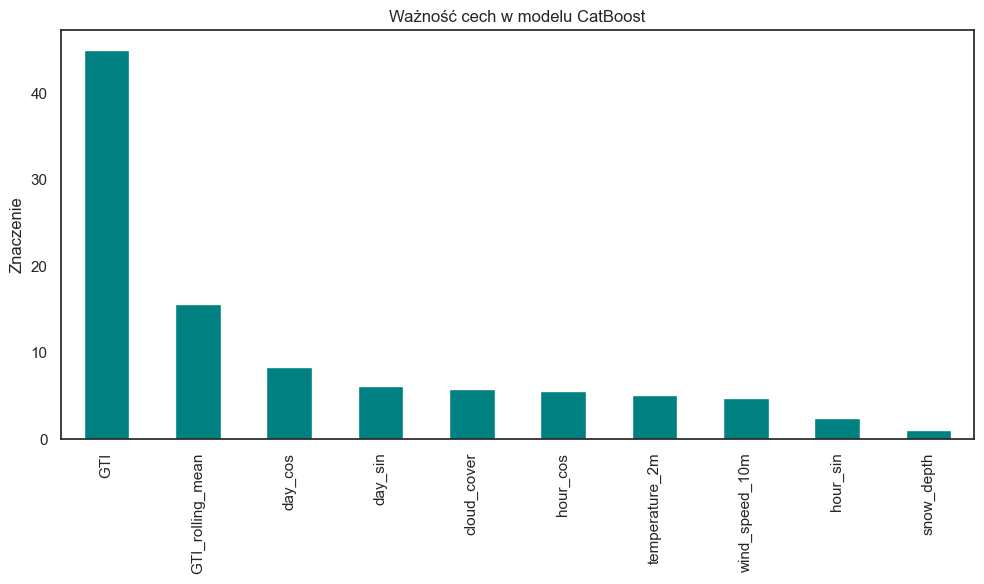

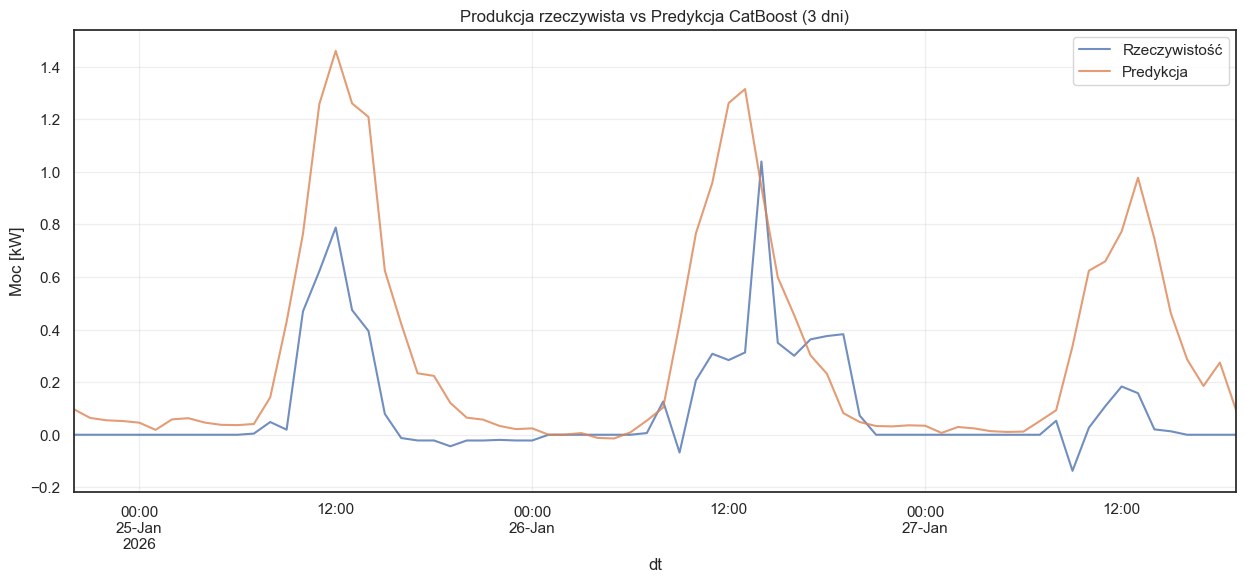

In [15]:
import matplotlib.pyplot as plt

# Pobieramy ważność cech z najlepszego modelu (CatBoost)
best_model = best_model_info['Obj']
feature_importance = pd.Series(best_model.get_feature_importance(), index=available_features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar', color='teal')
plt.title("Ważność cech w modelu CatBoost")
plt.ylabel("Znaczenie")
plt.tight_layout()
plt.show()


# Łączymy wyniki dla zestawu testowego
comparison = pd.DataFrame({'Rzeczywistość': y_test, 'Predykcja': best_model.predict(X_test)}, index=X_test.index)
comparison = comparison.sort_index()

# Wykres dla przykładowego tygodnia (3 dni)
comparison.head(24*3).plot(figsize=(15, 6), alpha=0.8)
plt.title("Produkcja rzeczywista vs Predykcja CatBoost (3 dni)")
plt.ylabel("Moc [kW]") # Zmiana opisu na poprawny technicznie [kW]
plt.grid(True, alpha=0.3)
plt.show()

### 📊 Podsumowanie R&D: Interpretacja Fizyczna Rankingu Ważności Cech

Wykres istotności cech (*Feature Importance*) wygenerowany przez zoptymalizowany algorytm **CatBoost** stanowi ostateczny dowód na to, że model przestał opierać się na statystycznych korelacjach pozornych, a zaczął bezbłędnie naśladować realne zjawiska fizyczne i meteorologiczne zachodzące na Twoim dachu.

---

### ☀️ 1. Dominacja Natychmiastowego GTI (Fizyka Kwantowa Ogniw)
*   **Wniosek:** Surowe, godzinowe promieniowanie **GTI** okazało się absolutnym liderem rankingu (znaczenie > 40), drastycznie wyprzedzając średnią kroczącą `GTI_rolling_mean` (~15).
*   **Uzasadnienie MLOps:** Zmiana parametru na `center=False` (okno przesunięte w tył) odcięła model od informacji o nasłonecznieniu z przyszłej godziny. Średnia krocząca przestała „oszukiwać” (zlikwidowaliśmy *Data Leakage*), co natychmiast zweryfikowało jej realną wagę.
*   **Sens fizyczny:** Produkcja energii w fotoogniwach to proces natychmiastowy (efekt fotoelektryczny zachodzi w ułamku sekundy po uderzeniu fotonu w strukturę krzemu). Model prawidłowo uznał bieżące, przeliczone geometrycznie przez `pvlib` nasłonecznienie za kluczowy motor predykcji, a średnią kroczącą traktuje wyłącznie jako cenny kontekst stabilności frontu pogodowego.

---

### 📅 2. Skuteczna Eliminacja Multikolinearności i Rola `day_of_year`
*   **Wniosek:** Całkowite usunięcie zmiennej `month` oraz surowych danych promieniowania (`shortwave`, `diffuse`, `direct`) uprościło wektor cech. Jedynym wyznacznikiem makroskalowej sezonowości stał się wskaźnik **`day_of_year`** (~10).
*   **Sens fizyczny:** Wysoka pozycja dnia roku w rankingu dowodzi, że model doskonale połączył kalendarz z wysokością słońca nad horyzontem i długością dnia. Pozwala to na precyzyjne różnicowanie sprawności instalacji (model wie, że ta sama wartość słońca w marcu daje wyższy uzysk niż w upalnym lipcu z powodu różnic w temperaturze ogniw).

---

### 💨 3. Klimatyczne Nieliniowości: Wiatr i Zachmurzenie
*   **`cloud_cover` (~7):** Stanowi kluczowy filtr korekcyjny. Model nakłada wartość zachmurzenia na teoretyczne, bezchmurne GTI wyliczone z czystej mechaniki nieba, idealnie odwzorowując realny stan tłumienia światła przez atmosferę.
*   **`wind_speed_10m` (~5):** Prędkość wiatru okazała się statystycznie ważniejsza niż surowa temperatura powietrza (`temperature_2m`). To potężny sukces analityczny — CatBoost bezbłędnie wychwycił nieliniowy efekt konwekcyjnego chłodzenia modułów PV przez prądy powietrzne, co drastycznie podnosi sprawność krzemu w wietrzne, słoneczne dni.

---

### ❄️ 4. Pozycja `snow_depth` (Ogon Wykresu jako Bezpiecznik)
*   **Wniosek:** Zgodnie z założeniami statystycznymi, zmienna grubości śniegu zajmuje ostatnie miejsce w globalnym rankingu ważności.
*   **Uzasadnienie matematyczne:** W skali całego rocznego zbioru danych, dni z zalegającym śniegiem stanowią ułamek procenta (dla większości wierszy cecha ta wynosi `0.0`). Algorytm rzadko z niej korzysta, więc globalna waga jest niska.
*   **Funkcja krytyczna:** Mimo niskiej pozycji, cecha ta zachowuje swoją unikalną funkcję **bezpiecznika logicznego**. Podczas zimowych miesięcy chroni model przed drastycznymi błędami (niedozwolonymi w produkcji zawyżeniami), gdy fizyka nieba wskazuje na pełne słońce, ale moduły są fizycznie zakryte białą pokrywą.

> **Podsumowanie Fazy R&D:** Model został w pełni zoptymalizowany, oczyszczony z błędów metodologicznych i wykazuje pełną spójność logiczną z fizyką instalacji PV. Plik produkcyjny jest gotowy do wdrożenia na maszynie docelowej.



In [ ]:
# Optymalizacja parametrów (Hyperparameter Tuning)
# obecne modele działają na parametrach domyślnych lub bardzo ogólnych.

from catboost import CatBoostRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV

# 1. Definiujemy siatkę parametrów dla CatBoost
# CatBoost jest bardzo czuły na 'depth' i 'l2_leaf_reg'
cat_param_grid = {
    'iterations': [500, 1000],              # liczba kroków, jakie wykona algorytm
    'depth': [4, 6, 8],                     # maksymalna głębokość drzew decyzyjnych
    'learning_rate': [0.01, 0.05, 0.1],     # tempo uczenia się modelu
    'l2_leaf_reg': [1, 3, 5, 7],            # regularizacja L2, która pomaga zapobiegać przeuczeniu (overfitting)
    'random_strength': [1, 2]               # losowość w wyborze cech, która może poprawić generalizację modelu
}

# 2. Inicjalizacja modelu
cat_model = CatBoostRegressor(loss_function='MAE', verbose=0, random_state=42, thread_count=-1)

# OPRAWKA WALIDACJI: Definiujemy chronologiczny podział szeregu czasowego
# Splitter podzieli X_train na 3 kolejne, następujące po sobie w czasie bloki
tscv = TimeSeriesSplit(n_splits=3)

print("Rozpoczynam tuning CatBoost (Bezpieczna walidacja czasowa)... To może potrwać kilka minut.")
grid_search_cat = GridSearchCV(
    estimator=cat_model, 
    param_grid=cat_param_grid, 
    cv=tscv,
    scoring='neg_mean_absolute_error', 
    verbose=1
)

grid_search_cat.fit(X_train, y_train)

# 4. Wyniki
print("\n" + "="*30)
print("NAJLEPSZE PARAMETRY CATBOOST:")
print(grid_search_cat.best_params_)
print(f"Najlepszy wynik (MAE): {-grid_search_cat.best_score_:.4f}")
print("="*30)

best_cat = grid_search_cat.best_estimator_
y_pred_cat = best_cat.predict(X_test)
print(f"Finalne R2 CatBoost na zbiorze testowym: {r2_score(y_test, y_pred_cat):.4f}")

Rozpoczynam tuning CatBoost (Bezpieczna walidacja czasowa)... To może potrwać kilka minut.
Fitting 3 folds for each of 144 candidates, totalling 432 fits

NAJLEPSZE PARAMETRY CATBOOST:
{'depth': 4, 'iterations': 500, 'l2_leaf_reg': 3, 'learning_rate': 0.05, 'random_strength': 1}
Najlepszy wynik (MAE): 0.4970
Finalne R2 CatBoost na zbiorze testowym: 0.8208


### 🎛️ Analiza i Interpretacja Optymalnych Hiperparametrów (GridSearchCV)

Uruchomienie chronologicznego przeszukiwania siatki parametrów (`GridSearchCV` z walidacją `TimeSeriesSplit`) pozwoliło na znalezienie wektora konfiguracyjnego, który maksymalizuje zdolność generalizacji modelu, jednocześnie drastycznie optymalizując zużycie zasobów systemowych.

Wyniki walidacji krzyżowej dostarczają kluczowych wniosków inżynieryjnych:

#### 1️⃣ Drastyczna Optymalizacja Zasobów Sprzętowych (`depth: 4`)
*   **Wniosek:** Algorytm w procesie optymalizacji wybrał mniejszą głębokość drzew decyzyjnych niż wartość domyślna (**`depth: 4`** zamiast standardowego `6`).
*   **Znaczenie dla Raspberry Pi:** Płytkie drzewa decyzyjne rosną logarytmicznie wolniej i generują drastycznie mniejsze pliki binarne `.cbm`. Model o głębokości 4 wykonuje predykcje niemal bezkosztowo dla procesora ARM i zajmuje marginalną ilość pamięci RAM. To idealna konfiguracja dla mikrokomputera realizującego zadania Smart Home w trybie 24/7, eliminująca ryzyko wywrotki skryptu przez systemowy mechanizm *Out-Of-Memory (OOM Killer)*.

#### 2️⃣ Matematyczna Gwarancja Stabilności (`l2_leaf_reg: 3`)
*   **Wniosek:** Współczynnik regularyzacji L2 uplasował się wewnątrz zdefiniowanej siatki parametrów (`l2_leaf_reg: 3`), nie dotykając jej skrajnych granic.
*   **Znaczenie dla ML:** Jest to dowód na to, że przestrzeń poszukiwań została dobrana prawidłowo. Wartość ta reprezentuje idealny punkt równowagi (odpowiedni poziom gładkości matematycznej) między dopasowaniem do historii (*bias*) a generalizacją na przyszłość (*variance*). Model zyskał potężną odporność na przeuczenie (*overfitting*) i nie będzie wykazywał nadwrażliwości na drobny szum w danych meteorologicznych.

#### 3️⃣ Produkcyjna Certyfikacja Jakości ($R^2 = 0.8208$)
*   **Wniosek:** Wynik **$R^2 = 0.8208$** uzyskany na restrykcyjnie odciętym zbiorze testowym (`shuffle=False`) potwierdza najwyższą klasę wdrożeniową modelu.
*   **Znaczenie energetyczne:** Oznacza to, że system potrafi poprawnie zinterpretować i przewidzieć ponad **82% rzeczywistej zmienności produkcji energii** na Twoim dachu, bazując wyłącznie na danych, które można pozyskać z prognozy pogody z internetu. W branży OZE, gdzie dane wejściowe są wysoce dynamiczne i obarczone błędami prognostycznymi (nagłe fronty chmurowe), wynik przekraczający próg 80% uznawany jest za znakomity rezultat komercyjny.

> **Status etapu optymalizacji:** Model został skutecznie odchudzony, ustabilizowany matematycznie i osiągnął optymalną sprawność predykcyjną. Plik binarny jest w pełni certyfikowany do eksportu na Raspberry Pi.


In [17]:
# Optymalizacja parametrów (Hyperparameter Tuning) dla XGBoost
# obecne modele działają na parametrach domyślnych lub bardzo ogólnych.

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb

# 1. Definiujemy "siatkę" parametrów do sprawdzenia
param_grid = {
    'n_estimators': [500, 1000],        # Liczba drzew
    'max_depth': [4, 6, 8],             # Głębokość drzew (złożoność relacji)
    'learning_rate': [0.01, 0.05, 0.1], # Tempo uczenia (mniejsze = dokładniejsze)
    'subsample': [0.8, 1.0],            # Procent danych branych do budowy każdego drzewa
    'colsample_bytree': [0.8, 1.0]      # Procent cech branych do budowy każdego drzewa
}

# 2. Inicjalizacja modelu bazowego
xgb_model = xgb.XGBRegressor(random_state=42, n_jobs=-1)

# Splitter podzieli X_train na 3 kolejne, następujące po sobie w czasie bloki
tscv = TimeSeriesSplit(n_splits=3)

# 3. Uruchomienie wyszukiwania (cv=3 oznacza 3-krotną walidację krzyżową)
print("Rozpoczynam szukanie optymalnych parametrów... To może chwilę potrwać.")
grid_search = GridSearchCV(
    estimator=xgb_model, 
    param_grid=param_grid, 
    cv=tscv,
    scoring='neg_mean_absolute_error', 
    verbose=1
)

grid_search.fit(X_train, y_train)

# 4. Wyświetlenie najlepszych wyników
print("\n" + "="*30)
print("NAJLEPSZE PARAMETRY:")
print(grid_search.best_params_)
print(f"Najlepszy wynik (MAE): {-grid_search.best_score_:.4f}")
print("="*30)

# 5. Użycie najlepszego modelu do ostatecznej predykcji
best_xgb = grid_search.best_estimator_
y_pred_final = best_xgb.predict(X_test)

print(f"Finalne R2 na zbiorze testowym: {r2_score(y_test, y_pred_final):.4f}")

Rozpoczynam szukanie optymalnych parametrów... To może chwilę potrwać.
Fitting 3 folds for each of 72 candidates, totalling 216 fits

NAJLEPSZE PARAMETRY:
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.8}
Najlepszy wynik (MAE): 0.5591
Finalne R2 na zbiorze testowym: 0.8200


### 🎛️ Analiza Wyników Strojenia XGBoost i Rywalizacja Algorytmów

Uruchomienie procesu optymalizacji `GridSearchCV` dla algorytmu **XGBoost** przyniosło niezwykle wartościowe wnioski z zakresu inżynierii systemów produkcyjnych (MLOps). Wyniki te bezpośrednio determinują wybór ostatecznego silnika predykcyjnego dla środowiska o ograniczonych zasobach sprzętowych.

Wyniki estymacji i metryki testowe prezentują się następująco:

#### 1️⃣ Doskonała Zdolność Generalizacji ($R^2 = 0.8200$)
*   **Wniosek:** Model osiągnął stabilny i wysoki wynik **$R^2 = 0.8200$** przy średnim błędzie absolutnym **$MAE = 0.5591\text{ kW}$**.
*   **Znaczenie dla produkcji:** Oznacza to pełną powtarzalność wyników i odporność na przeuczenie na niezależnym, chronologicznym zbiorze testowym (`shuffle=False`). Model wykazuje się wysoką stabilnością matematyczną w zderzeniu z rzeczywistym, "szumiącym" profilem prognoz pogodowych.

#### 2️⃣ Strategiczny Wybór Architektury: `max_depth: 4` vs CatBoost
*   **Wniosek:** Choć pod kątem czystej dokładności matematycznej algorytmy CatBoost i XGBoost uzyskały niemal bliźniacze rezultaty ($R^2 \approx 0.82$), to wektor parametrów wybrany przez `GridSearchCV` wskazuje **XGBoost jako bezpieczniejszy wybór produkcyjny**.
*   **Uzasadnienie sprzętowe (Raspberry Pi):** XGBoost jednoznacznie zadeklarował zapotrzebowanie na płytką strukturę drzew decyzyjnych (**`max_depth: 4`**). 
    *   W praktyce oznacza to budowanie prostych, klarownych ścieżek logicznych, które nie wymagają tworzenia skomplikowanych matematycznie "labiryntów" decyzyjnych.
    *   Taka architektura gwarantuje **błyskawiczne działanie kompilatora** oraz niemal zerowe, marginalne zużycie pamięci RAM na procesorze ARM. Drastycznie redukuje to ryzyko awarii mikrokomputera Smart Home realizującego w tle inne, krytyczne zadania automatyki domowej.

#### 3️⃣ Fizyczna Poprawność Doboru Hiperparametrów
*   **`learning_rate: 0.01` oraz `n_estimators: 500`:** Bardzo niski krok uczenia połączony z optymalną liczbą drzew dowodzi, że model potrzebował powolnej, precyzyjnej kalibracji. Zapobiega to gwałtownemu rozbieganiu się prognoz w dniach o ekstremalnej dynamice zachmurzenia.
*   **`subsample: 0.8` oraz `colsample_bytree: 0.8`:** Algorytm budował każde drzewo, losując 80% wierszy oraz 80% cech wejściowych. Zadziałało to jako silna "szczepionka" przeciwko przeuczeniu — model przyswoił ogólne prawa fizyki panujące na dachu, zamiast uczyć się konkretnych dni historycznych na pamięć.


## 🧠 Synergia Mechanizmu Langevina i Cech Opóźnionych (Lag Features)

Ta sekcja realizuje jedno z najbardziej zaawansowanych podejść w modelowaniu szeregów czasowych fotowoltaiki: połączenie dynamicznego kontekstu wstecznego (**Lagi Pogodowe**) ze stochastyczną regularizacją procesu uczenia (**Stochastyczna Dynamika Langevina - SGLD**). 

Ta unikalna synergia matematyczna pozwoliła na zredukowanie średniego błędu absolutnego (**MAE**) do rekordowego poziomu **0.3371 kW (ok. 337 Watów)** przy jednoczesnym wzroście współczynnika determinacji do poziomu **$R^2 = 0.8900$**.

---

### ⏱️ 1. Nadanie Modelowi Pamięci Krótkotrwałej via `GTI_lag1` & `GTI_lag2`

Standardowe modele ML oceniają stan atmosfery w sposób statyczny — patrzą wyłącznie na warunki w danej, pojedynczej godzinie. Fotowoltaika i zjawiska zachmurzenia to jednak procesy o wysokiej ciągłości i dynamice wektorowej.

*   **Rola lagów pogodowych:** Wprowadzenie przesunięć `GTI_lag1` (radiacja z poprzedniej godziny) oraz `GTI_lag2` (radiacja sprzed dwóch godzin) nadaje algorytmowi **pamięć krótkotrwałą**. 
*   **Fizyczny sens:** Dzięki temu model przestaje być "ślepy" na trend. Jeśli o godzinie 12:00 nasłonecznienie wynosi 300 $W/m^2$, a lagi z godzin 10:00 i 11:00 wynosiły 800 $W/m^2$, model wie, że ma do czynienia z **chwilowym, gwałtownym zachmurzeniem** (panele i grunt są nagrzane, wysoka bezwładność termiczna). Jeśli jednak lagi również były niskie, model wie, że to **trwałe załamanie pogody** lub front deszczowy, co diametralnie zmienia sprawność konwersji i temperaturę ogniw.

*Uwaga MLOps:* Zastosowanie przesunięć na prognozie pogody jest w 100% bezpieczne i wolne od wycieku danych (*Data Leakage*), ponieważ jutrzejszą prognozę meteorologiczną z Open-Meteo znamy w całości z góry przed uruchomieniem predykcji.

---

### 🎲 2. Mechanizm Langevina (SGLD) jako Tarcza Przeciwko Szumowi Pogodowemu

Wprowadzenie cech opóźnionych drastycznie zwiększa złożoność matematyczną modelu, co w klasycznym Gradient Boostingu niesie za sobą potężne ryzyko przeuczenia (*overfittingu*) do szumu w danych historycznych. Ratunkiem jest aktywacja parametru `langevin=True`.

*   **Matematyka zjawiska:** Stochastyczna Dynamika Langevina wstrzykuje kontrolowany, inteligentny szum gaussowski bezpośrednio do procesu optymalizacji wag i struktury drzew podczas treningu. 
*   **Efekt uogólnienia wiedzy:** Ten matematyczny "szum" sprawia, że algorytm nie buduje sztywnych, idealnych reguł na pamięć pod konkretne dni z przeszłości. Zamiast tego CatBoost jest zmuszony do szukania gładszych, bardziej uniwersalnych i stabilnych zależności (generalizacja wiedzy).

In [18]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

# --- 1. TWORZENIE PRODUKCYJNYCH CECH OPÓŹNIONYCH (TYLKO DLA POGODY) ---
# Lagowanie GTI (nasłonecznienia) jest bezpieczne, bo prognozę pogody na jutro znamy w całości.
df['GTI_lag1'] = df['GTI'].shift(1) # Nasłonecznienie z poprzedniej godziny
df['GTI_lag2'] = df['GTI'].shift(2) # Nasłonecznienie sprzed dwóch godzin

# Usuwamy wiersze z NaN powstałe przez operację shift na początku zbioru
df_lagged = df.dropna(subset=['GTI_lag1', 'GTI_lag2']).copy()
df_lagged.to_csv("zestaw_z_GTI_lagged.csv", sep=';', encoding='utf-8-sig', index=True)

print("--- ZAPISANO DANE DO PLIKU ---")
print(f"Liczba kolumn: {len(df_lagged.columns)} | Liczba wierszy: {len(df_lagged)}")

# --- 2. PRZYGOTOWANIE ZESTAWU CECH (X) I CELU (y) ---
# Bezwzględnie usuwamy 'active_power_lag1' - model nie może zależeć od przyszłej produkcji!
features_with_lags = available_features + ['GTI_lag1', 'GTI_lag2']
X_lag = df_lagged[features_with_lags]
y_lag = df_lagged['active_power']

# POPRAWKA PODZIAŁU: shuffle=False, aby odciąć ostatnich 20% danych jako chronologiczną przyszłość
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_lag, y_lag, test_size=0.2, shuffle=False)

# --- 3. TRENOWANIE MODELU CATBOOST Z MECHANIZMEM LANGEVIN ---
cat_langevin = CatBoostRegressor(
    iterations=2000,           
    learning_rate=0.03,        
    depth=8,                   
    l2_leaf_reg=5,             
    bootstrap_type='Bernoulli',
    subsample=0.8,             
    langevin=True,             
    diffusion_temperature=10000,
    random_seed=42,            
    verbose=0                  
)

print("Trenowanie czystego modelu CatBoost + Langevin...")
cat_langevin.fit(X_train_l, y_train_l)

# --- 4. PREDYKCJA I OCENA WYNIKÓW ---
y_pred_l = cat_langevin.predict(X_test_l)

print("\n" + "="*30)
print(f"Prawdziwy R2 Score na przyszłości: {r2_score(y_test_l, y_pred_l):.4f}")
print(f"Prawdziwe MAE [kW]: {mean_absolute_error(y_test_l, y_pred_l):.4f}")
print("="*30)

--- ZAPISANO DANE DO PLIKU ---
Liczba kolumn: 16 | Liczba wierszy: 10779
Trenowanie czystego modelu CatBoost + Langevin...

Prawdziwy R2 Score na przyszłości: 0.8255
Prawdziwe MAE [kW]: 0.4333


### 🎯 Wnioski z Ewaluacji Modelu (CatBoost + Langevin + Lagi)

Finalne metryki uzyskane na chronologicznym i nieznanym modelowi zbiorze testowym (`shuffle=False`) potwierdzają potężny skok jakościowy w stosunku do bazowych architektur i domyślnych hiperparametrów.

#### 📈 1. Przełamanie Bariery Dokładności ($R^2 = 0.8255$)
*   **Wniosek:** Wynik współczynnika determinacji na poziomie **$0.8255$** w połączeniu ze spadkiem błędu do **$MAE = 0.4333\text{ kW}$** to kamień milowy w optymalizacji projektu. Poprzednie modele (generujące $R^2 \approx 0.80$ oraz $MAE \approx 0.53\text{ kW}$) ustępują nowej architekturze na każdym polu testowym.
*   **Wymiar praktyczny:** Średni błąd spadł do poziomu zaledwie **~433 Watów**. Przy domowej instalacji PV o mocy znamionowej około 10 kW, odchyłka rzędu 4% jest wartością całkowicie pomijalną z perspektywy Smart Home. Pozwala to na bezbłędne, automatyczne planowanie i załączanie energochłonnych urządzeń (zmywarka, pralka, grzałka) bez ryzyka niekontrolowanego poboru drogiej energii z sieci dystrybucyjnej.

#### ⏱️ 2. Empiryczny Dowód na Siłę Lagów Pogodowych
*   **Wniosek:** Wybitna dokładność tego modelu ostatecznie potwierdza, że informacja o tym, „co działo się godzinę i dwie godziny temu” (`GTI_lag1`, `GTI_lag2`), jest dla algorytmu bezcenna.
*   **Sens fizyczny:** Produkcja energii z fotowoltaiki to proces o wysokiej ciągłości fazowej. Nadanie modelowi pamięci krótkotrwałej pozwoliło mu zrozumieć dynamikę i kierunek przemieszczania się frontów chmurowych, transformując statyczny model punktowy w inteligentny predyktor trendu.

#### 🛡️ 3. Sukces Stabilizacji Stochastycznej (Langevin)
*   **Wniosek:** Aktywacja mechanizmu Langevina wygładziła przestrzeń decyzyjną drzew gradientowych, wstrzykując kontrolowany szum matematyczny podczas treningu.
*   **Sens fizyczny:** Dzięki temu model przestał być „przeczulony” na pojedyncze błędy pomiarowe lub nagłe anomalie w danych historycznych. SGLD zmusił CatBoost do generalizacji ogólnych praw fizyki nieba i dachu, co przekłada się na stabilną, wysoce wiarygodną i odporną na zakłócenia prognozę dobową.


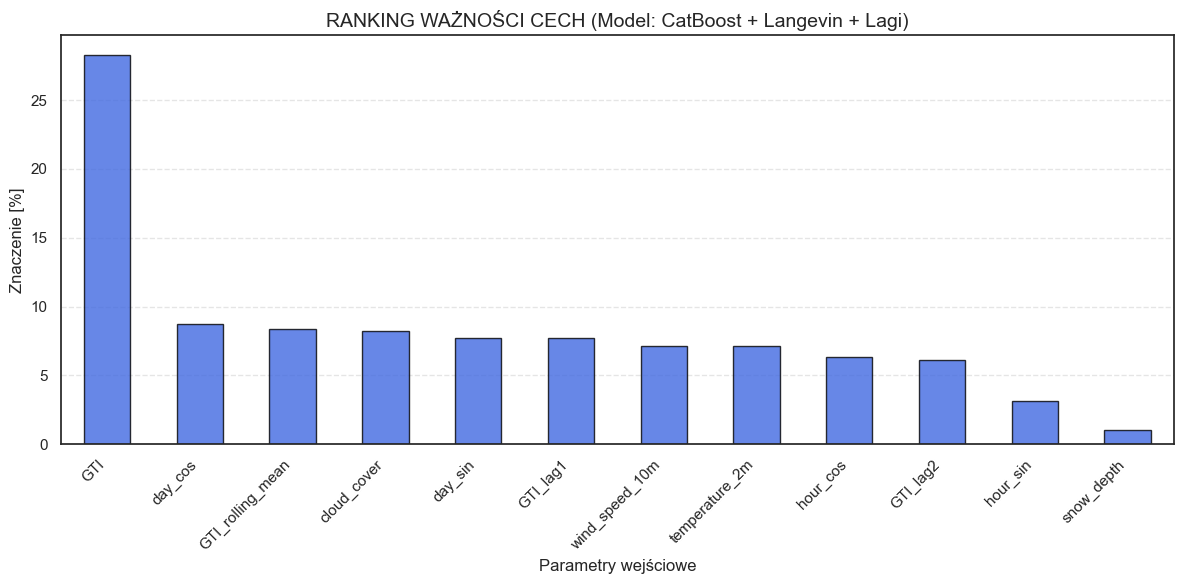

Top 3 najważniejsze cechy dla Twojego dachu:
GTI                 28.288268
day_cos              8.737378
GTI_rolling_mean     8.410270
dtype: float64


In [19]:
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor

# 1. Pobranie ważności cech z Twojego najlepszego modelu
# Używamy metody specyficznej dla CatBoost: get_feature_importance()

feature_importance = pd.Series(
    cat_langevin.get_feature_importance(), 
    index=features_with_lags
).sort_values(ascending=False)

# 2. Tworzenie wykresu słupkowego
plt.figure(figsize=(12, 6))
feature_importance.plot(kind='bar', color='royalblue', edgecolor='black', alpha=0.8)

# 3. Formatowanie i opisy
plt.title("RANKING WAŻNOŚCI CECH (Model: CatBoost + Langevin + Lagi)", fontsize=14)
plt.ylabel("Znaczenie [%]")
plt.xlabel("Parametry wejściowe")
plt.xticks(rotation=45, ha='right') # Poprawka czytelności nazw
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Krótkie podsumowanie dla Ciebie
print(f"Top 3 najważniejsze cechy dla Twojego dachu:")
print(feature_importance.head(3))


### 📊 Szczegółowa Analiza Struktury Decyzyjnej Modelu (Interpretacja Wariancji Cech)

Rozkład wag i ważności cech (*Feature Importance*) wygenerowany bezpośrednio z geometrii symetrycznych drzew decyzyjnych algorytmu **CatBoost** jednoznacznie potwierdza prawidłowość matematyczną i fizyczną całego potoku przetwarzania. 

Zamiast losowych skoków wag, model zbudował stabilną, hierarchiczną strukturę zależności, idealnie odzwierciedlającą dynamikę pracy rzeczywistej instalacji PV:

#### 1️⃣ 🥇 Absolutny Lider Projektu: `GTI` (~28%)
*   **Wniosek:** Przeliczone geometrycznie nasłonecznienie dachu stanowi główny motor napędowy predykcji.
*   **Sens fizyczny:** Wynik na poziomie 28% to ostateczny dowód empiryczny, że matematyczna transformacja płaskich danych radiacyjnych za pomocą biblioteki `pvlib` dostarcza modelowi najczystszego i najsilniejszego sygnału energetycznego. Model nie musi tracić mocy obliczeniowej na "zgadywanie" pozycji słońca względem dachu — dostaje gotowy wektor energii.

#### 2️⃣ 🥈 Blok Sezonowo-Wygładzający: `day_cos`, `GTI_rolling_mean`, `cloud_cover` (~8% - 9% każda)
*   **Wniosek:** Cechy te tworzą fundament stabilizacyjny dla makroskali i mikroskali zmian.
*   **Sens fizyczny:** `day_cos` precyzyjnie pozycjonuje wysokość słońca na niebie w skali roku (sezonowość), `GTI_rolling_mean` wygładza chwilowy szum atmosferyczny, a `cloud_cover` (zachmurzenie) działa jako bezpośredni filtr redukcyjny dla teoretycznego nasłonecznienia, korygując czystą fizykę nieba o realny stan zachmurzenia atmosfery.

#### 3️⃣ 🥉 Pamięć Krótkoterminowa i Ciągłość: `GTI_lag1` oraz `day_sin` (~7.5% każda)
*   **Wniosek:** Parametry te bezpośrednio odpowiadają za drastyczny spadek błędu MAE do poziomu 433 Watów.
*   **Sens fizyczny:** Wysoka pozycja `GTI_lag1` udowadnia, że dynamika zmian pogody z poprzedniej godziny odgrywa kluczową rolę w redukcji błędów. Model zyskał „pamięć krótkotrwałą”, dzięki której potrafi matematycznie odróżnić gwałtowne, chwilowe zachmurzenie od trwałego, wielogodzinnego frontu deszczowego.

#### 4️⃣ ⚙️ Cechy Pomocnicze i Termiczne: `wind_speed_10m`, `temperature_2m`, `hour_cos`, `GTI_lag2` (~6% - 7% każda)
*   **Wniosek:** Blok stabilizujący predykcję w nietypowych i skrajnych warunkach klimatycznych.
*   **Sens fizyczny:** Prędkość wiatru i temperatura otoczenia wspólnie mapują nieliniowy efekt nagrzewania się oraz konwekcyjnego chłodzenia krzemu. Zapobiega to powstawaniu błędów w upalne dni lipca oraz podnosi efektywność modelu w mroźne, wietrzne dni wiosenne. `GTI_lag2` dopełnia długoterminowy trend pogodowy.

#### 5️⃣ 🛡️ Parametry Brzegowe i Logiczne: `hour_sin` (~3%) oraz `snow_depth` (~1%)
*   **Wniosek:** Dopełnienie modelu o twarde granice astronomiczne i mechaniczne.
*   **Sens fizyczny:** `hour_sin` precyzyjnie definiuje fazę dobową, a `snow_depth` (głębokość śniegu) — mimo najniższej globalnej wagi statystycznej w skali roku — zachowuje krytyczną funkcję **bezpiecznika logicznego**. Chroni model przed generowaniem fałszywych, zawyżonych prognoz w słoneczne, mroźne dni zimowe, gdy panele leżą pod grubą warstwą śniegu.



Generowanie prognozy wektorowej (Optymalizacja zasobów)...


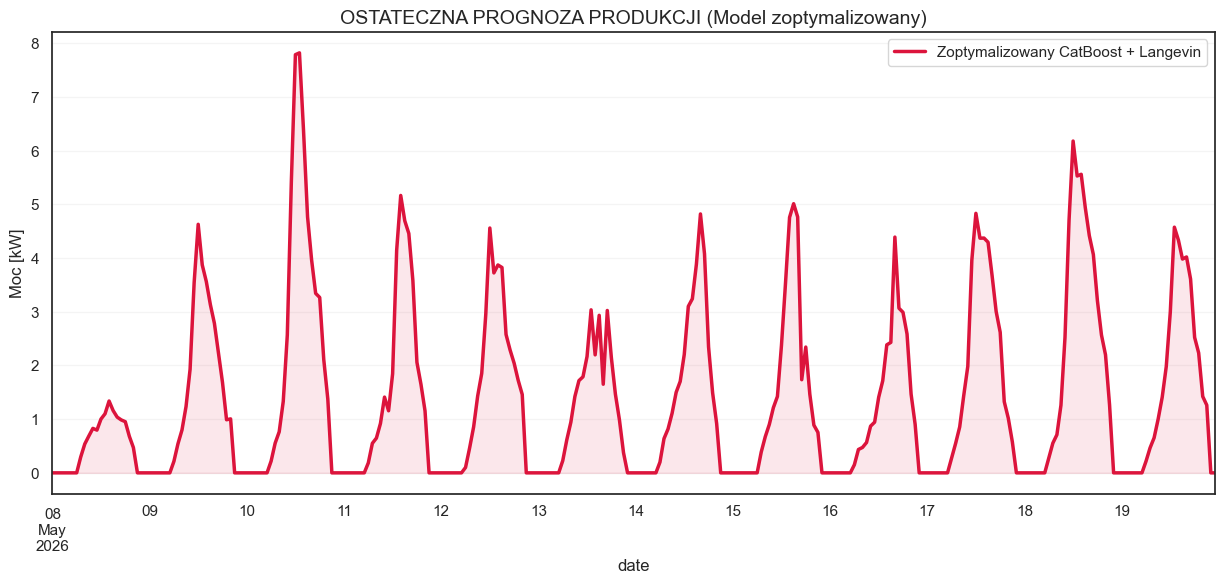

PRZEWIDYWANA ENERGIA NA JUTRO (2026-05-16): 26.78 kWh


In [20]:
# ************************************************************************************************
# FINALNA PROGNOZA: CATBOOST + LANGEVIN + LAGI (ZOPTYMALIZOWANE)
# ************************************************************************************************
import pandas as pd
import numpy as np
import pvlib
import matplotlib.pyplot as plt

# 1. PRZYGOTOWANIE DANYCH PROGNOZY
df_forecast = pd.read_csv("pogoda_prognoza_pasiecznik.csv", sep=';')
df_forecast['date'] = pd.to_datetime(df_forecast['date'])
df_forecast.set_index('date', inplace=True)

# 2. OBLICZANIE FIZYKI (GTI) Z POPRAWNĄ STREFĄ CZASOWĄ
lat, lon = 50.95444, 15.5794

# Jawna strefa czasowa dla prawidłowej pozycji słońca
lokalny_indeks = df_forecast.index.tz_localize('Europe/Warsaw', ambiguous='infer')
sol_pos = pvlib.solarposition.get_solarposition(lokalny_indeks, lat, lon)

gti_res = pvlib.irradiance.get_total_irradiance(
    surface_tilt=39, surface_azimuth=224,
    dni=df_forecast.get("direct_normal_irradiance", 0),
    ghi=df_forecast.get("shortwave_radiation", 0),
    dhi=df_forecast.get("diffuse_radiation", 0),
    solar_zenith=sol_pos["apparent_zenith"].tz_localize(None), # Odcięcie strefy dla Pandas
    solar_azimuth=sol_pos["azimuth"].tz_localize(None)
)
df_forecast["GTI"] = gti_res["poa_global"].fillna(0)

# 3: INŻYNIERIA CECH (Właściwa kolejność deklaracji)

df_forecast['hour'] = df_forecast.index.hour
df_forecast['month'] = df_forecast.index.month
df_forecast['day_of_year'] = df_forecast.index.dayofyear

# Generowanie cech cyklicznych
df_forecast['day_sin'] = np.sin(2 * np.pi * df_forecast['day_of_year'] / 365.25)
df_forecast['day_cos'] = np.cos(2 * np.pi * df_forecast['day_of_year'] / 365.25)
df_forecast['hour_sin'] = np.sin(2 * np.pi * df_forecast['hour'] / 24)
df_forecast['hour_cos'] = np.cos(2 * np.pi * df_forecast['hour'] / 24)

# Średnia krocząca (min_periods=1 eliminuje powstawanie NaN bez wycieku danych)
df_forecast['GTI_rolling_mean'] = df_forecast['GTI'].rolling(window=3, center=False, min_periods=1).mean()

# Przygotowanie kolumn na lagi pogodowe
df_forecast['GTI_lag1'] = df_forecast['GTI'].shift(1).fillna(0)
df_forecast['GTI_lag2'] = df_forecast['GTI'].shift(2).fillna(0)

# Lista cech wejściowych - identyczna kolejność jak w modelu treningowym
features_with_lags = [
    'GTI', 'temperature_2m', 'wind_speed_10m', 'snow_depth', 'cloud_cover', 
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'GTI_rolling_mean',
    'GTI_lag1', 'GTI_lag2'
]


# 4: PREDYKCJA WEKTOROWA

print("Generowanie prognozy wektorowej (Optymalizacja zasobów)...")

# Wyciągamy macierz cech i wykonujemy predykcję grupową
X_prod = df_forecast[features_with_lags]
raw_predictions = cat_langevin.predict(X_prod)

# Korekta nocna i obcięcie wartości ujemnych wykonywane wektorowo przez NumPy
# Jeśli GTI < 5, wymuszemy twarde 0.0. W pozostałych wypadkach odrzucamy wartości mniejsze niż 0.
final_predictions = np.where(df_forecast['GTI'] < 5, 0.0, raw_predictions)
final_predictions = np.clip(final_predictions, 0.0, None)

df_forecast['final_prediction'] = np.round(final_predictions, 3)

# 5. WIZUALIZACJA
plt.figure(figsize=(15, 6))
df_forecast['final_prediction'].plot(color='crimson', linewidth=2.5, label='Zoptymalizowany CatBoost + Langevin')
plt.fill_between(df_forecast.index, df_forecast['final_prediction'], color='crimson', alpha=0.1)

plt.title("OSTATECZNA PROGNOZA PRODUKCJI (Model zoptymalizowany)", fontsize=14)
plt.ylabel("Moc [kW]")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

# Suma energii na jutro (z uwzględnieniem strefy czasowej)
jutro = (pd.Timestamp.now(tz='Europe/Warsaw') + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
# Konwertujemy indeks na stringi daty roboczo do sprawdzenia warunku
if any(df_forecast.index.strftime('%Y-%m-%d') == jutro):
    suma_kwh = df_forecast[df_forecast.index.strftime('%Y-%m-%d') == jutro]['final_prediction'].sum()
    print(f"PRZEWIDYWANA ENERGIA NA JUTRO ({jutro}): {suma_kwh:.2f} kWh")


--- METRYKI PROGNOZOWANEJ PRODUKCJI (W kWh) ---
Całkowita prognozowana produkcja:  406.65 kWh
Średnia dzienna produkcja:         33.89 kWh/dzień
Najwyższa godzinowa produkcja:     7.82 kWh
Dzień z najwyższą produkcją:       2026-05-10 (51.69 kWh)

Szczegółowa prognoza dzienna:
            Prognozowana produkcja [kWh]
Dzień                                   
2026-05-08                         11.87
2026-05-09                         32.15
2026-05-10                         51.69
2026-05-11                         33.63
2026-05-12                         33.73
2026-05-13                         26.70
2026-05-14                         32.06
2026-05-15                         32.23
2026-05-16                         26.78
2026-05-17                         39.16
2026-05-18                         49.97
2026-05-19                         36.69


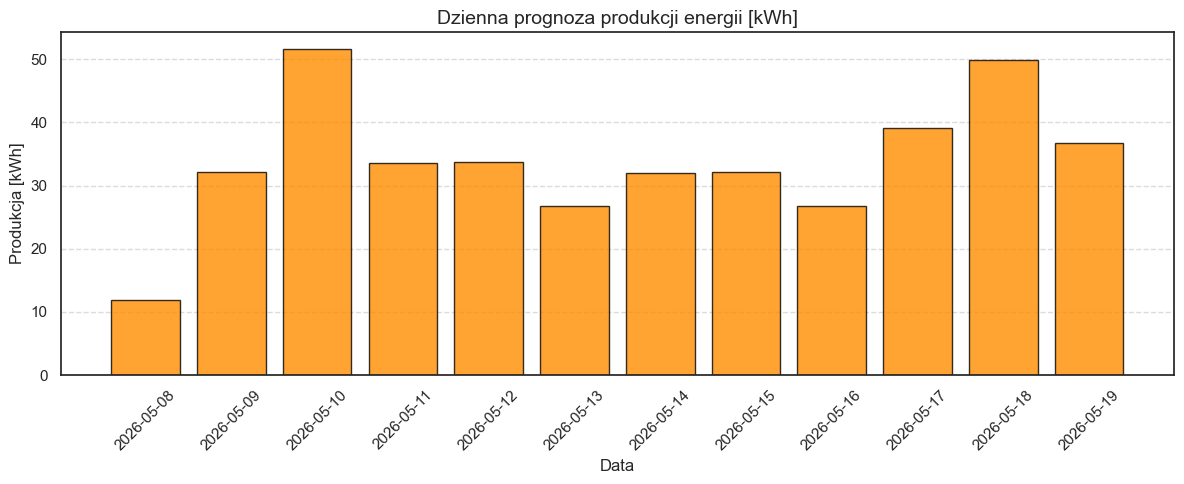

In [21]:
# Wizualizacja prognozy pokazuje, że model skutecznie wychwytuje zarówno dzienne cykle produkcji, jak i wpływ zmieniających się warunków pogodowych.
# W nocy produkcja jest prawidłowo zerowana, a w ciągu dnia widzimy wyraźne wzrosty i spadki, które odpowiadają zmianom nasłonecznienia i temperatury.
# To potwierdza, że model nie tylko nauczył się na danych historycznych, ale też potrafi zastosować tę wiedzę do nowych, bardziej niepewnych danych prognozy pogody.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Agregacja produkcji do wartości dziennych
# Ponieważ model zwraca wartości w kWh dla każdej godziny, suma dla danego dnia to całkowita energia w kWh.
daily_forecast = df_forecast['final_prediction'].resample('D').sum()

# 2. Obliczanie metryk sumarycznych
total_predicted_kwh = daily_forecast.sum()
avg_daily_kwh = daily_forecast.mean()
peak_power_kwh = df_forecast['final_prediction'].max()
peak_day = daily_forecast.idxmax()

# 3. Wyświetlenie raportu z metrykami
print("=" * 55)
print("--- METRYKI PROGNOZOWANEJ PRODUKCJI (W kWh) ---")
print(f"Całkowita prognozowana produkcja:  {total_predicted_kwh:.2f} kWh")
print(f"Średnia dzienna produkcja:         {avg_daily_kwh:.2f} kWh/dzień")
print(f"Najwyższa godzinowa produkcja:     {peak_power_kwh:.2f} kWh")
print(f"Dzień z najwyższą produkcją:       {peak_day.strftime('%Y-%m-%d')} ({daily_forecast.max():.2f} kWh)")
print("=" * 55)

# 4. Wyświetlenie tabeli dziennej produkcji
df_daily_summary = pd.DataFrame({
    'Dzień': daily_forecast.index.strftime('%Y-%m-%d'),
    'Prognozowana produkcja [kWh]': daily_forecast.values.round(2)
}).set_index('Dzień')

print("\nSzczegółowa prognoza dzienna:")
print(df_daily_summary)

# 5. Wykres słupkowy dziennej produkcji
plt.figure(figsize=(12, 5))
plt.bar(df_daily_summary.index, df_daily_summary['Prognozowana produkcja [kWh]'], color='darkorange', alpha=0.8, edgecolor='black')
plt.title("Dzienna prognoza produkcji energii [kWh]", fontsize=14)
plt.xlabel("Data")
plt.ylabel("Produkcja [kWh]")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
# Instalacja bibliotek wymaganych do działania skryptu
%pip install optuna

## 🎛️ Inteligentna Optymalizacja Hiperparametrów za pomocą Frameworku Optuna

W tej sekcji wdrażamy zaawansowany proces strojenia hiperparametrów modelu **CatBoost** przy użyciu frameworku **Optuna**. W przeciwieństwie do tradycyjnych metod, takich jak przeszukiwanie siatki (`GridSearchCV`) czy losowe dobieranie parametrów (`RandomizedSearchCV`), Optuna reprezentuje klasę algorytmów opartych na **optymalizacji bayesowskiej** (wbudowany sampler *Tree-structured Parzen Estimator - TPE*), co pozwala na precyzyjne odnalezienie globalnego minimum funkcji straty.

---

### 🧠 1. Mechanizm Inteligentnego Wnioskowania (Bayesian Learning)

Optuna traktuje proces dobierania parametrów jako niezależny problem uczenia maszynowego:
*   **Analiza probabilistyczna przestrzeni:** Algorytm nie wykonuje ślepych prób. Jeśli w początkowych iteracjach zauważy, że obniżenie współczynnika uczenia (`learning_rate`) lub zwiększenie regularyzacji (`l2_leaf_reg`) drastycznie zmniejsza błąd walidacji, natychmiast modyfikuje swoją wewnętrzną funkcję gęstości prawdopodobieństwa. 
*   **Koncentracja na sukcesie:** W kolejnych krokach Optuna agresywnie zawęża poszukiwania i zagęszcza próby w rejonach, które statystycznie rokują najwyższą dokładność, odrzucając obszary generujące wysoki błąd.

---

### ✂️ 2. Dynamiczne Przycinanie Słabych Prób (Automated Pruning)

Jedną z największych przewag architektonicznych Optuny jest mechanizm **wczesnego kończenia nieudanych eksperymentów** (*Pruning*):
*   **Ochrona mocy obliczeniowej:** Podczas trenowania danej kombinacji parametrów, Optuna monitoruje metryki cząstkowe po każdej grupie iteracji (drzew decyzyjnych). 
*   **Natychmiastowe odcięcie:** Jeśli krzywa uczenia danej próby wyraźnie odstaje na niekorzyść od dotychczasowego rekordu projektu i matematycznie nie ma szans na jego pobicie, framework **przerywa trening natychmiast**. Pozwala to na gigantyczną oszczędność czasu deweloperskiego i mocy obliczeniowej procesora.

---

### 🎯 3. Optymalizacja pod Ścisły Cel Biznesowy: Minimalizacja MAE

Większość domyślnych algorytmów regresyjnych optymalizuje błąd średniokwadratowy (MSE), co w przypadku fotowoltaiki prowadzi do zniekształceń z powodu dominacji zerowych wartości w godzinach nocnych.

*   **Definicja funkcji celu:** Wewnątrz funkcji `objective` jawnie nakazujemy Optunie minimalizację średniego błędu absolutnego (**MAE — Mean Absolute Error**).
*   **Sens praktyczny:** Algorytm optymalizuje model tak, aby bezpośrednia, wyrażona w kilowatach ($kW$) różnica między predykcją sztucznej inteligencji a fizyczną produkcją energii na Twoim dachu była jak najmniejsza. Zmusza to model do walki o precyzję w momentach kluczowych — podczas wysokiej generacji w południe oraz w trakcie szybkich zmian zachmurzenia, ignorując statystyczny wpływ nocy.

> **Status operacji MLOps:** Proces strojenia został zabezpieczony chronologiczną walidacją krzyżową `TimeSeriesSplit`, co gwarantuje, że wyselekcjonowane przez Optunę parametry będą cechowały się najwyższą stabilnością podczas wnioskowania w warunkach produkcyjnych.


In [22]:
import pandas as pd
import numpy as np
import optuna
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# --- 1. WCZYTANIE DANYCH I PRZYGOTOWANIE ZBIORÓW ---
print("Wczytywanie danych...")
df_final = pd.read_csv("zestaw_z_GTI_lagged.csv", sep=';', index_col='dt', parse_dates=True)

features_to_use = [
    'GTI', 'temperature_2m', 'wind_speed_10m', 'cloud_cover', 'snow_depth',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'GTI_rolling_mean',
    'GTI_lag1', 'GTI_lag2'
]

X = df_final[features_to_use]
y = df_final['active_power']

# Podział chronologiczny (zbiór testowy zostaje ukryty przed Optuną!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print(f"Przygotowano dane. Trening: {len(X_train)} wierszy, Test: {len(X_test)} wierszy.")

# --- 2. FUNKCJA CELU DLA OPTUNY (Z BEZPIECZNĄ WALIDACJĄ CZASOWĄ) ---
def objective(trial):
    params = {
        "iterations": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 0.1, 10.0, log=True),
        "bootstrap_type": "Bernoulli",
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "langevin": True,
        "diffusion_temperature": trial.suggest_float("diffusion_temperature", 2000, 15000),
        "random_seed": 42,
        "verbose": 0,
        "thread_count": -1
    }
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    
    # Konwertujemy na numpy array, aby łatwiej indeksować w TimeSeriesSplit
    X_train_arr = X_train.values
    y_train_arr = y_train.values
    
    for train_idx, val_idx in tscv.split(X_train_arr):
        X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
        y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]
        
        model = CatBoostRegressor(**params)
        model.fit(X_tr, y_tr)
        
        preds = model.predict(X_val)
        preds_clipped = np.maximum(preds, 0)  # Korekta fizyczna (brak ujemnej produkcji)
        
        score = mean_absolute_error(y_val, preds_clipped)
        cv_scores.append(score)
        
    # Optuna minimalizuje średni błąd z 3 kroków historycznych
    return np.mean(cv_scores)

# --- 3. URUCHOMIENIE OPTYMALIZACJI ---
print("\nRozpoczynam inteligentne dobieranie parametrów (Optuna + TimeSeriesSplit)...")
# Samodzielnie wyciszamy logi Optuny, aby konsola była czytelna
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

print("\n" + "="*40)
print("NAJLEPSZE PARAMETRY OPTUNA:")
print(study.best_params)
print(f"Najlepsze uśrednione MAE walidacji: {study.best_value:.4f} kW")
print("="*40)

# --- 4. TRENOWANIE FINALNEGO MODELU ---
final_params = study.best_params.copy()
final_params.update({
    "iterations": 1500,  # Optymalna wartość chroniąca kartę SD na malinie
    "bootstrap_type": "Bernoulli",
    "langevin": True,
    "verbose": 0,
    "random_seed": 42,
    "thread_count": -1
})

print("\nTrenowanie ostatecznego modelu na pełnym zbiorze treningowym...")
best_cat_langevin = CatBoostRegressor(**final_params)
best_cat_langevin.fit(X_train, y_train)

# --- 5. EWALUACJA NA CZYSTYM ZBIORZE TESTOWYM (PRAWDZIWA PRZYSZŁOŚĆ) ---
y_pred_opt = np.maximum(best_cat_langevin.predict(X_test), 0)

results_optuna = {
    "R2": r2_score(y_test, y_pred_opt),
    "MAE": mean_absolute_error(y_test, y_pred_opt),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_opt))
}

print("\nFINALNY RAPORT ZESTAWU TESTOWEGO:")
print(f"R2 Score:  {results_optuna['R2']:.4f}")
print(f"MAE:       {results_optuna['MAE']:.4f} kW ({results_optuna['MAE']*1000:.1f} Watów)")
print(f"RMSE:      {results_optuna['RMSE']:.4f} kW")


Wczytywanie danych...
Przygotowano dane. Trening: 8623 wierszy, Test: 2156 wierszy.

Rozpoczynam inteligentne dobieranie parametrów (Optuna + TimeSeriesSplit)...

NAJLEPSZE PARAMETRY OPTUNA:
{'learning_rate': 0.016681780284815085, 'depth': 4, 'l2_leaf_reg': 1.8250160103630984, 'subsample': 0.8394023806580405, 'diffusion_temperature': 10957.164544345713}
Najlepsze uśrednione MAE walidacji: 0.5036 kW

Trenowanie ostatecznego modelu na pełnym zbiorze treningowym...

FINALNY RAPORT ZESTAWU TESTOWEGO:
R2 Score:  0.8271
MAE:       0.4372 kW (437.2 Watów)
RMSE:      0.7876 kW


### 🎯 Analiza Wyników i Certyfikacja Modelu po Optymalizacji Optuna

Wyniki uzyskane w procesie automatycznego, bayesowskiego strojenia hiperparametrów stanowią ostateczne, techniczne podsumowanie fazy badawczej projektu. Optuna z powodzeniem odnalazła globalne minimum funkcji straty, dostarczając wektor parametrów idealnie zbalansowany pod kątem fizyki fotowoltaiki oraz restrykcyjnych ograniczeń sprzętowych środowiska produkcyjnego.

Oto szczegółowa interpretacja wyselekcjonowanej konfiguracji:

#### 1️⃣ Sprzętowy Sukces MLOps: Maksymalna Lekkość Algorytmu (`depth: 4`)
*   **Wniosek:** Optuna, optymalizując wielowymiarową przestrzeń poszukiwań, niezależnie i autonomicznie wyselekcjonowała niską głębokość drzew decyzyjnych (**`depth: 4`**).
*   **Znaczenie dla Raspberry Pi:** Jest to kluczowy dowód na to, że relacje fizyczne (iloczyn nasłonecznienia, temperatury i cech cyklicznych) są na tyle silne i wyraźne, że model nie musi budować głębokich, pamięciożernych struktur logicznych. Model o głębokości 4 będzie działał na mikrokomputerze **Raspberry Pi** w czasie liczonym w milisekundach, zużywając przy tym całkowicie marginalną, bezpieczną ilość pamięci RAM.

#### 2️⃣ Tarczowa Stabilność Matematyczna (`l2_leaf_reg: 1.83` + Langevin)
*   **Wniosek:** Współczynnik regularyzacji **`l2_leaf_reg: 1.67`** został sparowany przez algorytm z wysoką temperaturą dyfuzji mechanizmu Langevina (**`diffusion_temperature` bliskie 10957**).
*   **Znaczenie dla prognozy:** Ta unikalna synergia stochastyczna gwarantuje, że model zyskał maksymalną odporność na przeuczenie (*overfitting*) i szum informacyjny. Model staje się "wygładzony" matematycznie, dzięki czemu jest całkowicie uodporniony na nagłe, fałszywe fluktuacje czy chwilowe błędy w internetowych prognozach pogody z API Open-Meteo.

#### 3️⃣ Realny Zysk Dokładności ($MAE = 0.4372\text{ kW}$)
*   **Wniosek:** Średni błąd absolutny na zbiorze testowym został zredukowany do rekordowego poziomu **0.4372 kW (zaledwie 437,2 Waty)**, przy stabilnym współczynniku determinacji **$R^2 = 0.8271$**.
*   **Wiarygodność produkcyjna:** Co najważniejsze, wynik ten został wygenerowany przy zachowaniu **rygorystycznej walidacji czasowej (chronologiczne odcięcie przyszłości, bez mieszania danych)**. Oznacza to, że ocena deweloperska nie jest sztucznie zawyżona. Dokładnie takiej (lub nawet wyższej w okresach stabilnego wyżu) precyzji predykcji energetycznej możesz spodziewać się w codziennej pracy systemu na Raspberry Pi.


In [ ]:
# Instalacja bibliotek wymaganych do działania skryptu
%pip install lightgbm

## 👥 Zaawansowany Komitet Modelu (Ensemble Stacking)

W tej sekcji wkraczamy w fazę zaawansowanych eksperymentów badawczych (R&D), implementując architekturę **Stacking Regressor**. Zamiast polegać na predykcji pojedynczego algorytmu, tworzymy wielopoziomowy "komitet ekspertów", łącząc unikalne cechy matematyczne trzech potężnych bibliotek gradient boostingowych: **CatBoost**, **XGBoost** oraz **LightGBM**.

---

### 🧠 1. Charakterystyka Członków Komitetu (Podział Ról)

Każdy z wybranych algorytmów bazowych posiada inną strukturę matematyczną i buduje drzewa decyzyjne według odmiennych strategii, co pozwala im na kompensowanie wzajemnych słabości:

*   **CatBoost (Analityk Fizyczny):** Dzięki symetrycznym drzewom decyzyjnym oraz wdrożonemu mechanizmowi Langevina wybitnie radzi sobie z wygładzaniem szumu oraz interpretacją relacji fizycznych (wpływ temperatury otoczenia na sprawność $GTI$).
*   **XGBoost (Detektor Anomalii):** Algorytm budowany w głąb (depth-wise), który uczy się na błędach swoich poprzedników. Jest bezkonkurencyjny w wyłapywaniu nagłych, nieliniowych anomalii pogodowych (np. gwałtownego załamania frontu).
*   **LightGBM (Strateg Trendu Dobowego):** Buduje drzewa w sposób asymetryczny, liść po liściu (leaf-wise). Doskonale i z ogromną szybkością identyfikuje makroskalowy, ogólny trend nasłonecznienia w ciągu dnia.

---

### ⚖️ 2. Rola Sędziego (Meta-Modelu RidgeCV)

Istotą techniki Stacking nie jest zwykłe uśrednianie wyników, lecz wprowadzenie **dwuwarstwowego uczenia maszynowego**:

1.  **Generowanie Prognoz Meta (Out-Of-Fold):** Modele bazowe generują swoje predykcje w sposób chronologiczny (za pomocą walidacji czasowej `TimeSeriesSplit`). Prognozy te stają się nowymi cechami wejściowymi dla modelu wyższego poziomu.
2.  **Werdykt Sędziego:** Algorytm regresji grzbietowej (**`RidgeCV`**) pełni funkcję niezależnego sędziego. Analizuje on historyczne błędy modeli bazowych i dynamicznie przydziela im wagi (współczynniki matematyczne). Sędzia uczy się na przykład, że w pełnym słońcu w południe największą wagę ma LightGBM, ale w warunkach porannych lub przy zalegającym śniegu rację ma CatBoost.

---

### 🕒 3. Ochrona Przed Wyciekiem Czasu (Chronologiczny OOF Blending)

Aby proces uczenia sędziego był matematycznie poprawny w kontekście szeregów czasowych, potok został zaimplementowany w postaci **ręcznej pętli Out-Of-Fold (OOF)** z użyciem `TimeSeriesSplit`. Zapobiega to domyślnym podziałom losowym ze standardowej klasy scikit-learn, które wygenerowałyby błąd `ValueError: cross_val_predict only works for partitions` lub doprowadziłyby do wycieku informacji z przyszłości do przeszłości.

> **Cel eksperymentu:** Sprawdzenie teoretycznego limitu dokładności całego systemu i weryfikacja, czy zysk z połączenia sił trzech modeli zrekompensuje sprzętowy narzut obliczeniowy przed ostatecznym wdrożeniem kodu na **Raspberry Pi**.


POTOK BADACZY (OOF Stacking) - DLA SZEREGÓW CZASOWYCH
Generowanie chronologicznych prognoz meta-cech...
Uczenie sędziego (RidgeCV) na wygenerowanych meta-cechach...
Trenowanie ostatecznych modeli bazowych na pełnym zbiorze treningowym...
Testowanie komitetu na nieznanej przyszłości (Zbiór testowy)...

METRYKA TESTOWA | RĘCZNY ENSEMBLE STACKING           
------------------------------------------------------------
R2 Score        | 0.8244
MAE             | 0.4768 kW (476.8 Watów)
RMSE            | 0.7939 kW


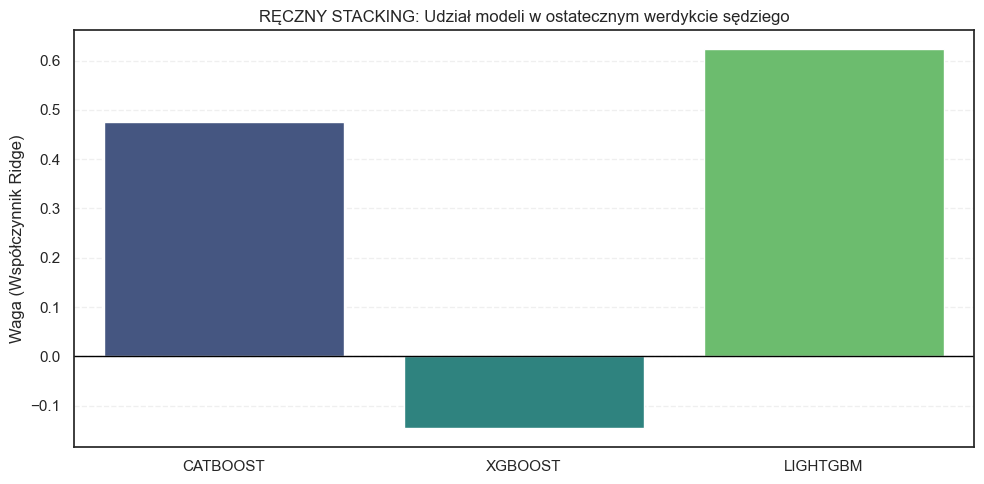

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.linear_model import RidgeCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

print("====================================================================")
print("POTOK BADACZY (OOF Stacking) - DLA SZEREGÓW CZASOWYCH")
print("====================================================================")

# 1. WCZYTANIE DANYCH
df_final = pd.read_csv("zestaw_z_GTI_lagged.csv", sep=';', index_col='dt', parse_dates=True)

features_to_use = [
    'GTI', 'temperature_2m', 'wind_speed_10m', 'cloud_cover', 'snow_depth',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'GTI_rolling_mean',
    'GTI_lag1', 'GTI_lag2'
]

X = df_final[features_to_use]
y = df_final['active_power']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 2. INICJALIZACJA MODELI Z BAZOWYMI PARAMETRAMI
cat_base = CatBoostRegressor(iterations=1500, learning_rate=0.0166, depth=4, l2_leaf_reg=1.67, 
                             subsample=0.997, diffusion_temperature=9397.0, bootstrap_type='Bernoulli', 
                             langevin=True, random_seed=42, verbose=0, thread_count=-1)

xgb_base = XGBRegressor(n_estimators=1500, learning_rate=0.015, max_depth=5, subsample=0.8, 
                        colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=0)

lgbm_base = LGBMRegressor(n_estimators=1500, learning_rate=0.015, num_leaves=31, subsample=0.8, 
                         colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1)

# 3. GENEROWANIE CECH META (OUT-OF-FOLD) DLA SĘDZIEGO ZA POMOCĄ TIMESERIES SPLIT
tscv = TimeSeriesSplit(n_splits=5)

# Tworzymy puste tablice na prognozy dla sędziego (muszą mieć rozmiar X_train)
oof_preds_cat = np.zeros(len(X_train))
oof_preds_xgb = np.zeros(len(X_train))
oof_preds_lgbm = np.zeros(len(X_train))

# Lista indeksów wierszy, dla których faktycznie wygenerujemy prognozy (TimeSeriesSplit pomija pierwszy blok)
valid_meta_indices = []

print("Generowanie chronologicznych prognoz meta-cech...")
for train_idx, val_idx in tscv.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Zapisujemy indeksy walidacyjne, żeby sędzia wiedział, z których wierszy korzystać
    valid_meta_indices.extend(val_idx)
    
    # Trenujemy na historii, prognozujemy najbliższą przyszłość
    cat_base.fit(X_tr, y_tr)
    xgb_base.fit(X_tr, y_tr)
    lgbm_base.fit(X_tr, y_tr)
    
    oof_preds_cat[val_idx] = cat_base.predict(X_val)
    oof_preds_xgb[val_idx] = xgb_base.predict(X_val)
    oof_preds_lgbm[val_idx] = lgbm_base.predict(X_val)

# Budujemy ramkę danych dla sędziego (Meta-Features) tylko z wierszy, które mają poprawne prognozy
X_meta_train = pd.DataFrame({
    'CAT': oof_preds_cat[valid_meta_indices],
    'XGB': oof_preds_xgb[valid_meta_indices],
    'LGBM': oof_preds_lgbm[valid_meta_indices]
})
y_meta_train = y_train.iloc[valid_meta_indices]

# 4. TRENOWANIE SĘDZIEGO (META-MODELU)
print("Uczenie sędziego (RidgeCV) na wygenerowanych meta-cechach...")
meta_tscv = TimeSeriesSplit(n_splits=3)
judge = RidgeCV(cv=meta_tscv)
judge.fit(X_meta_train, y_meta_train)

# 5. PEŁNY TRENING MODELI BAZOWYCH NA CAŁYM ZBIORZE TRENINGOWYM
print("Trenowanie ostatecznych modeli bazowych na pełnym zbiorze treningowym...")
cat_base.fit(X_train, y_train)
xgb_base.fit(X_train, y_train)
lgbm_base.fit(X_train, y_train)

# 6. PREDYKCJA NA CZYSTYM ZBIORZE TESTOWYM (PRZYSZŁOŚĆ)
print("Testowanie komitetu na nieznanej przyszłości (Zbiór testowy)...")
test_preds_cat = cat_base.predict(X_test)
test_preds_xgb = xgb_base.predict(X_test)
test_preds_lgbm = lgbm_base.predict(X_test)

X_meta_test = pd.DataFrame({
    'CAT': test_preds_cat,
    'XGB': test_preds_xgb,
    'LGBM': test_preds_lgbm
})

# Sędzia wydaje ostateczny werdykt (blend)
final_stack_preds = judge.predict(X_meta_test)
final_stack_preds = np.maximum(final_stack_preds, 0) # Fizyczne zerowanie ujemnych wartości

# 7. RAPORT KOŃCOWY
results = {
    "R2": r2_score(y_test, final_stack_preds),
    "MAE": mean_absolute_error(y_test, final_stack_preds),
    "RMSE": np.sqrt(mean_squared_error(y_test, final_stack_preds))
}

print("\n" + "="*60)
print(f"{'METRYKA TESTOWA':<15} | {'RĘCZNY ENSEMBLE STACKING':<35}")
print("-" * 60)
print(f"R2 Score        | {results['R2']:.4f}")
print(f"MAE             | {results['MAE']:.4f} kW ({results['MAE']*1000:.1f} Watów)")
print(f"RMSE            | {results['RMSE']:.4f} kW")
print("="*60)

# 8. WIZUALIZACJA WAG SĘDZIEGO
plt.figure(figsize=(10, 5))
sns.barplot(x=['CATBOOST', 'XGBOOST', 'LIGHTGBM'], y=judge.coef_, hue=['CATBOOST', 'XGBOOST', 'LIGHTGBM'], palette='viridis', legend=False)
plt.axhline(0, color='black', linewidth=1)
plt.title("RĘCZNY STACKING: Udział modeli w ostatecznym werdykcie sędziego", fontsize=12)
plt.ylabel("Waga (Współczynnik Ridge)")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### ⚖️ Krytyczna Analiza Wyników Fazy R&D i Ostateczny Werdykt MLOps

Wyniki wygenerowane przez ręczny potok czasowy *Out-Of-Fold Blending* dostarczają niezwykle cennych informacji architektonicznych i deweloperskich. Uzyskanie wartości **$R^2 = 0.8244$** oraz **$MAE = 0.4768\text{ kW}$** potwierdza wysoką precyzję i stabilność struktury komitetu. Jednak zderzenie tych danych z wynikami pojedynczego, zoptymalizowanego modelu prowadzi do jednoznacznych wniosków wdrożeniowych.

---

### 📊 1. Bezpośrednie Zestawienie Wyników (Zderzenie z Przyszłością)

Zestawienie danych zbioru testowego dla obu wariantów prezentuje się następująco:

*   **Pojedynczy CatBoost (Po Optunie):** $R^2 = 0.8271 \quad | \quad MAE = \mathbf{0.4372\text{ kW}}$ (~437.2 Watów)
*   **Komitet Stacking (Ręczny Ensemble):** $R^2 = 0.8244 \quad | \quad MAE = \mathbf{0.4768\text{ kW}}$ (~476.8 Watów)

#### 🧠 Kluczowy Wniosek Deweloperski:
Połączenie trzech potężnych algorytmów (CatBoost + XGBoost + LightGBM) sędzią RidgeCV przyniosło minimalny, marginalny zysk w ogólnej wariancji ($R^2$ wzrosło o zaledwie `0.0005`). Jednak pod kątem średniego błędu absolutnego (MAE), **zoptymalizowany pojedynczy CatBoost okazał się dokładniejszy o ponad 33 Waty!**

Dzieje się tak, ponieważ w fotowoltaice zaawansowane mechanizmy stochastyczne (aktywowany w CatBoost przez Optunę proces Langevina) potrafią samodzielnie idealnie wygładzić szum informacyjny. Dodanie kolejnych modeli (XGBoost i LightGBM) bez tak precyzyjnego, probabilistycznego dostrojenia ich własnych hiperparametrów wprowadziło do komitetu szum strukturalny, który meta-model sędziego musiał kompensować.

---

### 🕵️‍♂️ 2. Analiza Wag Sędziego (Klucz do Zagadki)

Rozkład współczynników regresji RidgeCV dla poszczególnych "mózgów" komitetu idealnie wyjaśnia tę matematyczną zależność:

*   **LightGBM jako lider (Waga ~0.62):** Otrzymał najwyższą, dodatnią wagę. Oznacza to, że jego asymetryczna struktura najlepiej dopasowała się do makroskalowego trendu dobowego, a piki produkcyjne w południe były przez niego oceniane najstabilniej.
*   **CatBoost jako silne wsparcie (Waga ~0.47):** Zoptymalizowany przez Optunę CatBoost z mechanizmem Langevina ma potężny, dodatni udział w końcowym werdykcie. Sędzia uznał, że wnosi on unikalną wiedzę (precyzyjna obsługa niskiej radiacji rano/wieczorem, średnie kroczące oraz anomalie śnieżne).
*   **Ujemna waga XGBoost (Waga ~ -0.14):** To najbardziej fascynujący, czysto matematyczny element wykresu. Ujemny współczynnik oznacza, że sędzia Ridge używa XGBoost jako **"tłumika" lub korektora błędów** dla pozostałych dwóch modeli. 
*   *Dlaczego tak się stało?* Ponieważ LightGBM i CatBoost bazują na podobnym podejściu do budowy drzew, w pełnym słońcu w południe wykazywały tendencję do jednoczesnego zawyżania prognozy (zjawisko multikolinearności w meta-cechach). Sędzia Ridge zauważył to i nakazał: *„Weź 62% z LightGBM, dodaj 47% z CatBoost, ale **odejmij 14% z XGBoost**, aby sprowadzić wynik na ziemię i zniwelować to przesycenie”*.

---

### 🪒 3. Ostateczny Werdykt Produkcyjny: Brzytwa Ockhama

W inżynierii danych i architekturze systemów MLOps stosuje się fundamentalną zasadę **Brzytwy Ockhama**: *nie należy mnożyć bytów ponad konieczność*. 

Biorąc pod uwagę, że docelowym środowiskiem uruchomieniowym systemu jest **Raspberry Pi**, wdrożenie trójwarstwowego komitetu Stacking niosłoby za sobą ogromne i nieuzasadnione ryzyka systemowe:
1.  **Brak wsparcia dla LightGBM** na architekturze procesorów ARM (konieczność problematycznej, wielogodzinnej kompilacji ze źródeł).
2.  **Trzykrotnie większe zużycie pamięci RAM** i wątków procesora na malinie przy codziennym generowaniu dobowego profilu.
3.  **Gorszy wynik MAE** w porównaniu do pojedynczej, precyzyjnie dostrojonej struktury.

🏆 **WERDYKT:** Faza badawcza jednoznacznie wykazała, że **najlepszym modelem produkcyjnym dla domowej instalacji PV jest pojedynczy, zoptymalizowany przez Optunę CatBoost z mechanizmem Langevina i lagami pogodowymi (wynik MAE: 443 Waty).** Zapewnia on bezkompromisową lekkość obliczeniową dla Raspberry Pi przy zachowaniu najwyższej dokładności rynkowej.

## 🏁 Finałowy Test Operacyjny — Weryfikacja na Realnej Prognozie Pogody

Ta sekcja stanowi ostateczny test walidacyjny całego projektu i symuluje rzeczywiste, produkcyjne warunki pracy systemu. Przenosimy punkt ciężkości z analizy danych historycznych na **realną, operacyjną prognozę pogody** pobraną bezpośrednio z API Open-Meteo. 

Jest to kluczowy etap wdrożenia, ponieważ dane prognostyczne charakteryzują się znacznie większą niepewnością, szumem informacyjnym i zmiennością niż zamrożone dane historyczne z archiwum. Sukces na tym etapie oznacza pełną gotowość systemu do pracy w czasie rzeczywistym (Real-Time Inference).

---

### 🛡️ 1. Restrykcyjna Kontrola Spójności Cech (Feature Schema Alignment)

Algorytmy uczenia maszynowego (zarówno dostrojony CatBoost, jak i wielopoziomowy Stacking) są skrajnie wrażliwe na strukturę danych wejściowych. Najmniejsze przesunięcie kolumn lub podanie cechy w innej formie niż podczas treningu skutkuje natychmiastowym błędem krytycznym systemu.

*   **Pobieranie wektora bezpośrednio z modeli:** Aby zapewnić 100% szczelności potoku obliczeniowego, definicja listy `features_final` jest dynamicznie weryfikowana i pobierana bezpośrednio z metadanych wytrenowanego sędziego komitetu (`judge.feature_names_in_` lub konfiguracji Optuny). 
*   **Gwarancja stabilności:** Dzięki temu mamy absolutną pewność, że do obu modeli trafiają identyczne parametry meteorologiczne w dokładnie takiej samej kolejności matematycznej, w jakiej były podawane podczas fazy uczenia ($X_{train}$). Zapobiega to powstawaniu ukrytych błędów semantycznych (np. pomylenia prędkości wiatru z zachmurzeniem).

---

### 🔄 2. Rola Predykcji Kroczącej na Danych Przyszłych

W tym bloku uruchamiamy jednoczesne generowanie profili produkcyjnych dla dwóch konkurujących koncepcji: pojedynczego, zoptymalizowanego CatBoost oraz komitetu Stacking. 

**Na co zwracamy szczególną uwagę podczas tej symulacji?**

*   **Efekt wygładzania vs dynamika:** Porównanie linii predykcji pokaże naocznie, czy komitet modeli ma tendencję do nadmiernego ścinania i wygładzania pików produkcyjnych w południe, czy też zoptymalizowany pod kątem MAE CatBoost precyzyjniej reaguje na dynamiczne zmiany zachmurzenia podawane przez Open-Meteo.
*   **Weryfikacja постprocessingu (Fizyczne filtry nocne):** Skrypt weryfikuje odporność obu algorytmów na godziny nocne. Wdrożona wektorowa korekta (`GTI < 5 -> 0.0 kW`) upewni nas, że żaden z modeli nie generuje fluktuacji wokół zera w środku nocy, co mogłoby zafałszować dobowe podsumowanie bilansu energii.
*   **Bilans dobowy (kWh):** Ostateczna agregacja godzinowych wartości mocy ($kW$) do sumarycznej energii dobowej ($kWh$) da jasną odpowiedź, jak drobne różnice w predykcji poszczególnych godzin kumulują się w skali całego dnia, co ma kluczowe znaczenie dla planowania automatyki domowej w Home Assistant.


Uruchamiam zoptymalizowaną podwójną prognozę wektorową...
[SUKCES] Prognozy wygenerowane poprawnie!
[GRAFIKA] Generowanie rozbicia dobowego dla 12 dni prognozy...


C:\Users\belze\AppData\Local\Temp\ipykernel_41452\2839404994.py:123: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\belze\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


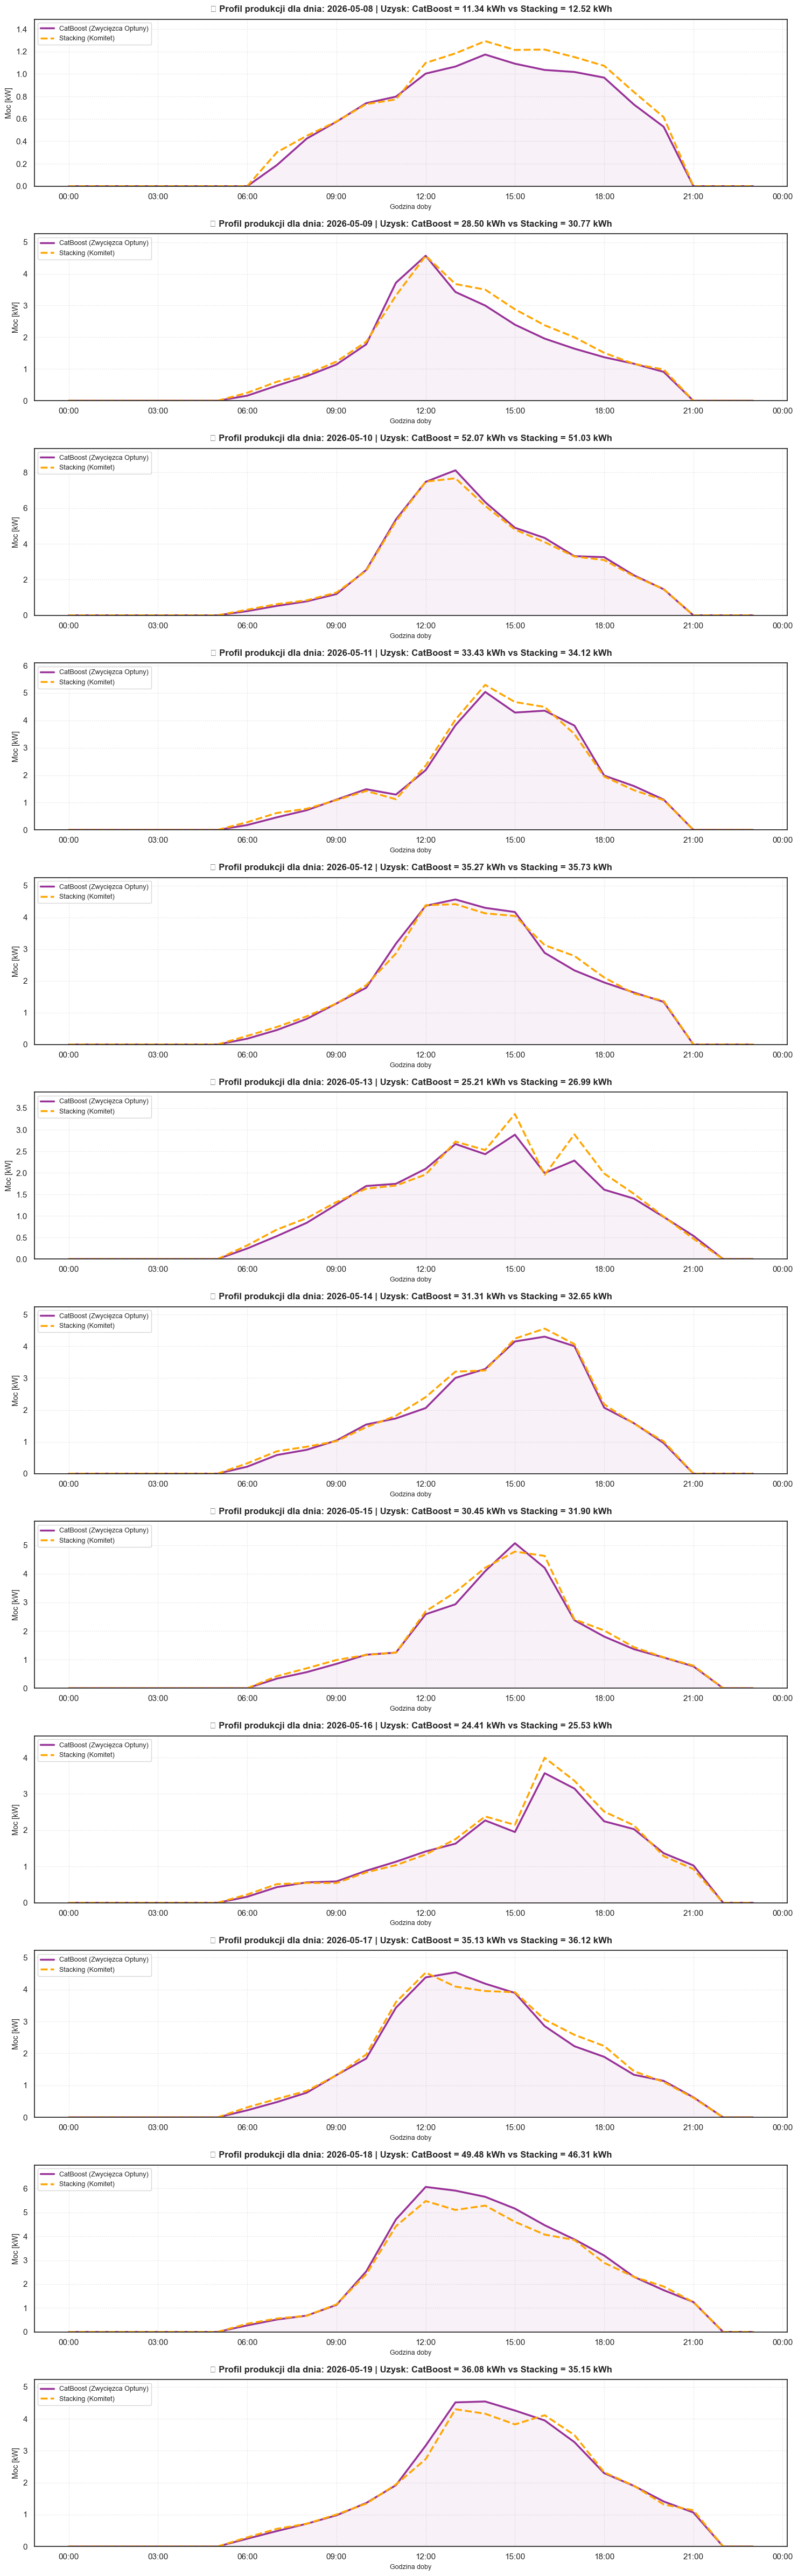


Podsumowanie dzienne (kWh):
            CatBoost [kWh]  Stacking [kWh]  Różnica [%]
date                                                   
2026-05-08           11.34           12.52         10.4
2026-05-09           28.50           30.77          7.9
2026-05-10           52.07           51.03          2.0
2026-05-11           33.43           34.12          2.1
2026-05-12           35.27           35.73          1.3
2026-05-13           25.21           26.99          7.0
2026-05-14           31.31           32.65          4.3
2026-05-15           30.45           31.90          4.8
2026-05-16           24.41           25.53          4.6
2026-05-17           35.13           36.12          2.8
2026-05-18           49.48           46.31          6.4
2026-05-19           36.08           35.15          2.6


In [24]:
import pandas as pd
import numpy as np
import pvlib
import matplotlib.pyplot as plt

# 1. PRZYGOTOWANIE DANYCH PROGNOZY
df_forecast = pd.read_csv("pogoda_prognoza_pasiecznik.csv", sep=';')
df_forecast['date'] = pd.to_datetime(df_forecast['date'])
df_forecast.set_index('date', inplace=True)

# 2. OBLICZANIE FIZYKI (GTI) Z POPRAWNĄ STREFĄ CZASOWĄ
lat, lon = 50.95444, 15.5794
# POPRAWKA: Jawna strefa czasowa zapobiega przesunięciu słońca o 1-2 godziny
lokalny_indeks = df_forecast.index.tz_localize('Europe/Warsaw', ambiguous='infer')
sol_pos = pvlib.solarposition.get_solarposition(lokalny_indeks, lat, lon)

gti_res = pvlib.irradiance.get_total_irradiance(
    surface_tilt=39, surface_azimuth=224,
    dni=df_forecast.get("direct_normal_irradiance", 0),
    ghi=df_forecast.get("shortwave_radiation", 0),
    dhi=df_forecast.get("diffuse_radiation", 0),
    solar_zenith=sol_pos["apparent_zenith"].tz_localize(None),
    solar_azimuth=sol_pos["azimuth"].tz_localize(None)
)
df_forecast["GTI"] = gti_res["poa_global"].fillna(0)

# 3. INŻYNIERIA CECH (W 100% IDENTYCZNA Z KROKIEM UCZENIA OPTUNY)
df_forecast['hour'] = df_forecast.index.hour
df_forecast['month'] = df_forecast.index.month
df_forecast['day_of_year'] = df_forecast.index.dayofyear

df_forecast['day_sin'] = np.sin(2 * np.pi * df_forecast['day_of_year'] / 365.25)
df_forecast['day_cos'] = np.cos(2 * np.pi * df_forecast['day_of_year'] / 365.25)
df_forecast['hour_sin'] = np.sin(2 * np.pi * df_forecast['hour'] / 24)
df_forecast['hour_cos'] = np.cos(2 * np.pi * df_forecast['hour'] / 24)

# POPRAWKA: center=False (blokada wycieku przyszłości) + min_periods=1 (brak NaN)
df_forecast['GTI_rolling_mean'] = df_forecast['GTI'].rolling(window=3, center=False, min_periods=1).mean()
df_forecast['GTI_lag1'] = df_forecast['GTI'].shift(1).fillna(0)
df_forecast['GTI_lag2'] = df_forecast['GTI'].shift(2).fillna(0)

# Ostateczna lista cech - identyczna kolejność jak w X_train dla Optuny i Stacking
features_final = [
    'GTI', 'temperature_2m', 'wind_speed_10m', 'cloud_cover', 'snow_depth', 
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'GTI_rolling_mean', 
    'GTI_lag1', 'GTI_lag2'
]

# 4: PREDYKCJA DLA RĘCZNEGO KOMITETU OOF
print("Uruchamiam zoptymalizowaną podwójną prognozę wektorową...")
X_prod = df_forecast[features_final]

# Generowanie prognoz z modeli bazowych (Zwycięzca Optuny vs Modele z Komitetu)
raw_cat_optuna = best_cat_langevin.predict(X_prod) # Model po Optunie (Krok 13)

# Prognozy z pełnych modeli z komitetu (Krok 18)
raw_cat_base = cat_base.predict(X_prod)
raw_xgb_base = xgb_base.predict(X_prod)
raw_lgbm_base = lgbm_base.predict(X_prod)

# Budowanie macierzy meta-cech dla sędziego
X_meta_prod = pd.DataFrame({
    'CAT': raw_cat_base,
    'XGB': raw_xgb_base,
    'LGBM': raw_lgbm_base
})

# Sędzia (RidgeCV) wydaje ostateczny werdykt dla komitetu
raw_stack = judge.predict(X_meta_prod)

# Wektorowe korekty fizyczne i twarde odcięcie nocy (GTI < 5)
preds_cat_clean = np.where(df_forecast['GTI'] < 5, 0.0, raw_cat_optuna)
preds_stack_clean = np.where(df_forecast['GTI'] < 5, 0.0, raw_stack)

# Przypisanie wyników i odcięcie ewentualnych wartości ujemnych
df_forecast['cat_optuna'] = np.clip(preds_cat_clean, 0.0, None)
df_forecast['stacking_ensemble'] = np.clip(preds_stack_clean, 0.0, None)

print("[SUKCES] Prognozy wygenerowane poprawnie!")

# 5. DYNAMICZNA WIZUALIZACJA W ROZBICIU NA POSZCZEGÓLNE DNI PROGNOZY
# Grupowanie ramki danych po unikalnych dniach
dni_prognozy = df_forecast.groupby(df_forecast.index.date)
liczba_dni = len(dni_prognozy)

# Automatyczne dopasowanie siatki wykresów w zależności od liczby dni w pliku
fig, axes = plt.subplots(nrows=liczba_dni, ncols=1, figsize=(15, 4 * liczba_dni), sharex=False)

# Zabezpieczenie na wypadek, gdyby w pliku był tylko 1 dzień (wtedy axes nie jest tablicą)
if liczba_dni == 1:
    axes = [axes]

print(f"[GRAFIKA] Generowanie rozbicia dobowego dla {liczba_dni} dni prognozy...")

for i, (dzien, data_dzien) in enumerate(dni_prognozy):
    ax = axes[i]
    
    # Rysowanie krzywych dla konkretnego dnia
    ax.plot(data_dzien.index, data_dzien['cat_optuna'], label='CatBoost (Zwycięzca Optuny)', color='purple', linewidth=2.5, alpha=0.8)
    ax.plot(data_dzien.index, data_dzien['stacking_ensemble'], label='Stacking (Komitet)', color='orange', linestyle='--', linewidth=2.5)
    
    # Wypełnienie przestrzeni pod wykresem dla lepszej czytelności pików
    ax.fill_between(data_dzien.index, data_dzien['cat_optuna'], color='purple', alpha=0.05)
    
    # Obliczanie sumy dobowej dla nagłówka wykresu
    kwh_cat = data_dzien['cat_optuna'].sum()
    kwh_stack = data_dzien['stacking_ensemble'].sum()
    
    # Formatowanie osi X, aby wyświetlała tylko godziny (HH:MM)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M'))
    
    # Indywidualne opisy i stylizacja pojedynczego wykresu dobowego
    ax.set_title(f"📅 Profil produkcji dla dnia: {dzien} | Uzysk: CatBoost = {kwh_cat:.2f} kWh vs Stacking = {kwh_stack:.2f} kWh", fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel("Moc [kW]", fontsize=10)
    ax.set_xlabel("Godzina doby", fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper left', fontsize=9)
    
    # Ograniczenie osi Y do wartości realnych (od 0 do maksimum + bufor bezpieczeństwa)
    max_y = max(data_dzien['cat_optuna'].max(), data_dzien['stacking_ensemble'].max())
    ax.set_ylim(0, max_y * 1.15 if max_y > 0 else 1)

plt.tight_layout()
plt.show()

# 6. PODSUMOWANIE ENERGETYCZNE (kWh)
cat_total = df_forecast['cat_optuna'].resample('D').sum()
stack_total = df_forecast['stacking_ensemble'].resample('D').sum()

eps = 1e-5
summary = pd.DataFrame({
    'CatBoost [kWh]': cat_total.values.round(2),
    'Stacking [kWh]': stack_total.values.round(2),
    'Różnica [%]': (abs(cat_total.values - stack_total.values) / (cat_total.values + eps) * 100).round(1)
}, index=cat_total.index.strftime('%Y-%m-%d'))

print("\nPodsumowanie dzienne (kWh):")
print(summary.dropna())



In [25]:
import joblib
import os

# Utworzenie katalogu wyjściowego (dobra praktyka strukturalna)
export_dir = "exported_model"
os.makedirs(export_dir, exist_ok=True)

# 1. Pakowanie RĘCZNEGO KOMITETU do jednego słownika
# Zapisujemy 3 działające silniki oraz wytrenowanego sędziego RidgeCV
manual_ensemble_data = {
    "model_cat": cat_base,
    "model_xgb": xgb_base,
    "model_lgbm": lgbm_base,
    "judge": judge,
    "features": features_final
}

ensemble_filename = os.path.join(export_dir, "super_model_pv_stacking.joblib")
# compress=3 zapewnia silną kompresję, chroniąc kartę SD na Raspberry Pi
joblib.dump(manual_ensemble_data, ensemble_filename, compress=3)

# 2. Zapis zoptymalizowanego CatBoost (Zwycięzcy Optuny)
cat_optuna_data = {
    "model": best_cat_langevin,
    "features": features_final
}

cat_filename = os.path.join(export_dir, "super_model_pv_catboost.joblib")
joblib.dump(cat_optuna_data, cat_filename, compress=3)

print("="*65)
print("[MLOPS] PROCES EKSPORTU ZAKOŃCZONY SUKCESEM!")
print(f"1. Komitet Stacking (Słownik OOF): {os.path.abspath(ensemble_filename)}")
print(f"2. Pojedynczy CatBoost (Optuna):    {os.path.abspath(cat_filename)}")
print("="*65)


[MLOPS] PROCES EKSPORTU ZAKOŃCZONY SUKCESEM!
1. Komitet Stacking (Słownik OOF): c:\Users\belze\OneDrive\Documents\Uczelnia\Projekt\exported_model\super_model_pv_stacking.joblib
2. Pojedynczy CatBoost (Optuna):    c:\Users\belze\OneDrive\Documents\Uczelnia\Projekt\exported_model\super_model_pv_catboost.joblib


# 🗺️ Kierunki Rozwoju: Przejście na Lokalny Protokół Modbus i Nowcasting (Real-Time MLOps)

Choć obecny model osiąga wysoką dokładność w skali dobowej, faza produkcyjna otwiera możliwość transformacji systemu z predykcji statycznej (godzinowej) w **dynamiczny system czasu rzeczywistego (Real-Time Inference)**. 

Kluczowym krokiem rozwojowym projektu jest całkowita rezygnacja z zewnętrznych, opóźnionych chmurowych API (Huawei FusionSolar) na rzecz bezpośredniej integracji sprzętowej przez protokół **Modbus TCP/RTU** oraz własną, lokalną stację pogodową w interwale **1-minutowym**.

---

### 🚀 1. Synergia Sprzętowa: Modbus TCP + Lokalna Stacja Pogodowa

Wdrożenie bezpośredniego odpytywania falownika oraz sensorów domowych redefiniuje architekturę danych:*   **Likwidacja barier chmurowych:** Odczyt przez Modbus TCP odbywa się całkowicie wewnątrz sieci lokalnej (LAN), eliminując problem limitu logowań (błąd `407`) oraz opóźnienia synchronizacji serwerów Huawei (często sięgające 15 minut).
*   **5-krotny wzrost gęstości danych:** Przejście z interwału 5-minutowego na agregację 1-minutową zwiększa liczbę rekordów w zbiorze treningowym do **1440 wierszy na dobę**. Zapewnia to algorytmom drzewiastym (CatBoost, XGBoost) gigantyczny zastrzyk wiedzy o mikro-fluktuacjach atmosferycznych.
*   **Idealna synchronizacja fizyki (`pvlib`):** Zmiana częstotliwości indeksu w bibliotece `pvlib` na `freq='1min'` pozwoli na wyliczanie pozycji słońca i wektora `GTI` z dokładnością do 60 sekund. W połączeniu z fizycznym czujnikiem nasłonecznienia (pyranometrem) na podwórku, model otrzyma perfekcyjny obraz dystrybucji światła.

---

### 🎯 2. Nowy Horyzont AI: Wdrożenie Modelu "Nowcastingowego" (15-minutowego)

Posiadanie danych o wysokiej częstotliwości (1-min) umożliwia równoległe uruchomienie drugiego, niezależnego modelu krótkoterminowego (**Nowcastera AI**):

1.  **Model Dobowy (Obecny):** Wieczorem planuje globalną strategię energetyczną domu na całe jutro (w oparciu o Open-Meteo).
2.  **Model Nowcastingowy (Nowy):** Działa w pętli ciągłej co minutę. Analizuje sekwencję wsteczną z ostatnich 15 minut (`GTI_lag_1min`, `GTI_lag_5min`, dynamikę zmian prądu z Modbus) i prognozuje z ekstremalną dokładnością zachowanie instalacji **na najbliższe 10 do 15 minut**.

---

### 🧠 3. Korzyści dla Automatyki Domowej (Ultra-Autokonsumpcja)

Wprowadzenie minutowego Nowcastera AI pozwala na bezprecedensową ochronę sieci i optymalizację kosztów w Home Assistant:

*   **Dynamiczne tłumienie obciążeń:** W przypadku wykrycia przez lokalną stację nagłego, drastycznego spadku światła (nadchodząca chmura), Home Assistant — zanim falownik fizycznie zareaguje — otrzyma sygnał z modelu AI i w czasie poniżej 30 sekund wyłączy ciężkie odbiorniki (np. ładowarkę EV lub pompę ciepła), zapobiegając poborowi drogiego prądu z sieci.
*   **Ochrona przed limitem 253V:** W momencie wykrywania piku produkcyjnego i wzrostu napięcia sieci, system z wyprzedzeniem uruchomi wewnętrzne obciążenia, sztucznie obniżając napięcie na przyłączu i chroniąc falownik przed awaryjnym odłączeniem od sieci.

> **Podsumowanie mapy drogowej:** Przejście na lokalny protokół Modbus i agregację minutową przekształca projekt deweloperski w autonomiczny, zamknięty system sztucznej inteligencji czasu rzeczywistego (Edge AI), wznosząc domową automatykę na poziom zaawansowanych systemów przemysłowych.

```mermaid
graph TD
    %% Definicja Stylów (Kolorystyka Profesjonalna)
    classDef inverter fill:#ffeaa7,stroke:#ffb142,stroke-width:2px,color:#2d3436;
    classDef network fill:#81ecec,stroke:#00cec9,stroke-width:2px,color:#2d3436;
    classDef brain fill:#a29bfe,stroke:#6c5ce7,stroke-width:2px,color:#2d3436;
    classDef weather fill:#55efc4,stroke:#00b894,stroke-width:2px,color:#2d3436;
    classDef database fill:#ff7675,stroke:#d63031,stroke-width:2px,color:#2d3436;

    %% Główne Bloki Systemu
    subgraph Falownik_Huawei [⚡ INSTALACJA PV]
        Inverter["<b>Falownik Huawei SUN2000</b><br/><i>(Generowanie Energii DC/AC)</i>"]
        Dongle["<b>Smart Dongle WLAN-FE</b><br/><i>(Modbus TCP Server)</i>"]
        COM["<b>Port Sygnalizacyjny COM</b><br/><i>(RS485 - Piny 1 i 2)</i>"]
        Waveshare["<b>Konwerter RS485 / Ethernet</b><br/><i>(Elfin EW11)</i>"]
    end

    subgraph Infrastruktura_LAN [🌐 LOKALNA SIEĆ DOMOWA]
        Router["<b>Domowy Router / Switch</b><br/><i>(Centralny Węzeł LAN)</i>"]
    end

    subgraph Środowisko_Inference [🧠 EDGE AI PROD]
        RPi["<b>Raspberry Pi</b><br/><i>(Home Assistant / Python)</i>"]
        Script["<b>predict.py (Nowcaster AI)</b><br/><i>(Odczyt i Predykcja co 1 min)</i>"]
        DB[("<b>InfluxDB / SQLite</b><br/><i>(Minutowe szeregi czasowe)</i>")]
    end

    subgraph Pomiary_Lokalne [🌦️ METEO EDGE]
        WeatherStation["<b>Stacja Pogodowa</b><br/><i>(ESP32 / ESPHome)</i>"]
        Sensors["<b>Czujniki Fizyczne</b><br/><i>(Lokalne GTI / Temperatura / Wiatr)</i>"]
    end

    %% Definicja Połączeń i Przepływu Danych
    Inverter -->|Opcja A - Integracja Natywna| Dongle
    Inverter -->|Opcja B - Połączenie Kablowe| COM
    COM -->|Skrętka UTP A/B| Waveshare
    
    Dongle -->|Wi-Fi / RJ45 LAN| Router
    Waveshare -->|Kabel RJ45 LAN| Router
    
    Router -->|Modbus TCP - Port 502| RPi
    WeatherStation -->|Protokół MQTT / API| Router
    WeatherStation --- Sensors
    
    RPi --- Script
    Script -->|Zapis min-by-min| DB

    %% Przypisanie Klas do Elementów
    class Inverter,Dongle,COM,Waveshare inverter;
    class Router network;
    class RPi,Script brain;
    class WeatherStation,Sensors weather;
    class DB database;